In [1]:
!pip list > libs.txt

# Progetto: Marzia Chetta, Ilaria Del Peschio Liberatore, Gemma Frigerio
Nell’ambito del Machine Learning e del corso di Coding, il presente progetto ha l’obiettivo di analizzare un dataset relativo ai dipendenti di un’azienda (le cui sedi inserite nel dataset si trovano in India), al fine di sviluppare modelli predittivi in grado di identificare se un dipendente lascerà o meno il proprio posto di lavoro (**variabile target: LeaveOrNot**). Questo tipo di analisi riveste una particolare rilevanza anche in ambito economico e manageriale, in quanto la capacità di prevedere l'abbandono dei dipendenti consente alle aziende di *implementare strategie di trattenimento più efficaci, riducendo i costi legati alla rotazione del personale e migliorando la produttività complessiva*. In particolare, il dataset in questione è stato pubblicato nel 2023 e tratta dei dipendenti di un'azienda con sedi in India, più precisamente:
* Bangalore: definita come la Silycon Valley Indiana, è un centro tecnologico e dell’innovazione, con un'elevata concentrazione di aziende IT e startup. Qui il lavoro è spesso legato al settore tecnologico, e lo stress da carichi intensi o la competitività possono influenzare la soddisfazione e la produttività dei dipendenti;
* New Delhi: capitale politica e amministrativa, rappresenta un centro nevralgico per imprese pubbliche e private. Le dinamiche lavorative qui possono riflettere una maggiore burocrazia, differente cultura aziendale e diversa distribuzione salariale.
* Pune: città universitaria e polo industriale in espansione, dove convivono imprese manifatturiere, educational e tecnologiche. Pune offre uno spaccato interessante di un ambiente lavorativo più giovane e dinamico.

Il dataset utilizzato è stato estratto da Kaggle e contiene *informazioni anagrafiche, professionali e comportamentali* relative a un campione di dipendenti. Essendo dati relativi ad un'azienda realmente esistente, sono protetti dall'anonimato. Le osservazioni includono sia variabili quantitative sia qualitative, ed è quindi necessario un lavoro preliminare di preprocessamento dei dati per renderli compatibili con i modelli predittivi.
Nel nostro progetto implementeremo e confronteremo tre modelli di classificazione (binaria) supervisionata:
1. **Support Vector Machine (SVM) con kernel** non lineare (RBF: Radial Basis Function), per identificare pattern complessi anche in spazi ad alta dimensionalità;
2. **Decision Tree**, per ottenere un modello interpretabile e facilmente visualizzabile;
3. **Regressione Logistica con Polynomial Feature Mapping**, per modellare relazioni non lineari mantenendo una base probabilistica nell’interpretazione dei risultati;
4. **AdaBoost**, modello di ensamble learning che utilizza più modelli Random Forest in modo sequenziale per migliorare le performance e ridurre l'errore, ottenendo così previsioni più accurate.

## Descrizione del Dataset
Il dataset contiene 8 variabili esplicative e 1 variabile target:
* **LeaveOrNot** (variabile target): indica se un dipendente ha lasciato l’azienda (Yes=1 / No=0).
* **Age**: età del dipendente.
* **Education**: titolo di studi posseduto (Bachelors: Laurea Triennale, Master, PHD: Dottorato).
* **ExperienceInCurrentDomain**: numero di anni di esperienza nel settore lavorativo di riferimento.
* **JoiningYear**: anno di ingresso nell'azienda.
* **Gender**
* **City**: la città in cui il dipendente lavora (Pune, Bangalore, New Delhi)
* **EverBenched**: se il dipendente è mai stato privato o escluso da un incarico.
* **PaymentTier**: categoria salariale del dipendente.

Dal punto di vista economico, l’abbandono del personale rappresenta un costo significativo per le imprese: include non solo i costi diretti di assunzione e formazione dei nuovi dipendenti, ma anche una perdita di produttività, know-how e coesione interna. L’uso di tecniche di Machine Learning permette di sfruttare i dati aziendali disponibili per **anticipare queste uscite**, adottare misure correttive personalizzate e risolvere il problema **dell'ottimizzazione delle risorse umane**. Inoltre, lo studio dei fattori che incidono sulla retention consente una più profonda comprensione delle dinamiche organizzative e delle preferenze individuali.

# FASE 1: Exploratory Data Analysis
Prima di procedere con l'applicazione dei quattro modelli precedentemente elencati, è necessario svolgere un'analisi preliminare del dataset per individuare eventuali valori nulli, duplicati, irrilevanti, e valutare, attraverso analisi univariate, bivariate e multivariate, la distribuzione dei dati.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [4]:
emp=pd.read_csv("Employee.csv")

In [6]:
emp.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1


In [8]:
emp.tail()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0
4652,Bachelors,2015,Bangalore,3,33,Male,Yes,4,0


In [10]:
emp.shape

(4653, 9)

In [12]:
emp.duplicated().sum() 

1889

In [14]:
emp=emp.drop_duplicates()

Con il metodo drop_duplicates() abbiamo rimosso tutte le righe duplicate del dataset in quanto introducono rumore poichè rappresentano lavoratori con le stesse identiche caratteristiche.

In [17]:
emp.shape

(2764, 9)

In [19]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2764 entries, 0 to 4651
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  2764 non-null   object
 1   JoiningYear                2764 non-null   int64 
 2   City                       2764 non-null   object
 3   PaymentTier                2764 non-null   int64 
 4   Age                        2764 non-null   int64 
 5   Gender                     2764 non-null   object
 6   EverBenched                2764 non-null   object
 7   ExperienceInCurrentDomain  2764 non-null   int64 
 8   LeaveOrNot                 2764 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 215.9+ KB


In [21]:
emp.isnull().sum()

Education                    0
JoiningYear                  0
City                         0
PaymentTier                  0
Age                          0
Gender                       0
EverBenched                  0
ExperienceInCurrentDomain    0
LeaveOrNot                   0
dtype: int64

In [23]:
print(emp['Education'].value_counts())
print(emp['City'].value_counts())
print(emp['Gender'].value_counts())
print(emp['EverBenched'].value_counts())

Education
Bachelors    1971
Masters       637
PHD           156
Name: count, dtype: int64
City
Bangalore    1171
Pune          801
New Delhi     792
Name: count, dtype: int64
Gender
Male      1529
Female    1235
Name: count, dtype: int64
EverBenched
No     2403
Yes     361
Name: count, dtype: int64


Dopo aver verificato la presenza di righe duplicate ed averle eliminate, aver constatato che il dataset non presenta elementi mancanti, si può procedere alla trasformazione delle colonne categoriche testuali, in numeriche.

In [27]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
emp['Education']=le.fit_transform(emp['Education'])
emp['City']=le.fit_transform(emp['City'])
emp['Gender']=le.fit_transform(emp['Gender'])
emp['EverBenched']=le.fit_transform(emp['EverBenched'])

In [29]:
emp.head()

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,0,2017,0,3,34,1,0,0,0
1,0,2013,2,1,28,0,0,3,1
2,0,2014,1,3,38,0,0,2,0
3,1,2016,0,3,27,1,0,5,1
4,1,2017,2,3,24,1,1,2,1


In [31]:
print(emp['Education'].value_counts())
print(emp['City'].value_counts())
print(emp['Gender'].value_counts())
print(emp['EverBenched'].value_counts())

Education
0    1971
1     637
2     156
Name: count, dtype: int64
City
0    1171
2     801
1     792
Name: count, dtype: int64
Gender
1    1529
0    1235
Name: count, dtype: int64
EverBenched
0    2403
1     361
Name: count, dtype: int64


In [33]:
emp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2764 entries, 0 to 4651
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education                  2764 non-null   int64
 1   JoiningYear                2764 non-null   int64
 2   City                       2764 non-null   int64
 3   PaymentTier                2764 non-null   int64
 4   Age                        2764 non-null   int64
 5   Gender                     2764 non-null   int64
 6   EverBenched                2764 non-null   int64
 7   ExperienceInCurrentDomain  2764 non-null   int64
 8   LeaveOrNot                 2764 non-null   int64
dtypes: int64(9)
memory usage: 215.9 KB


Adesso il dataset è pronto per essere processato.

## Verifichiamo che il dataset non sia eccessivamente sbilanciato:

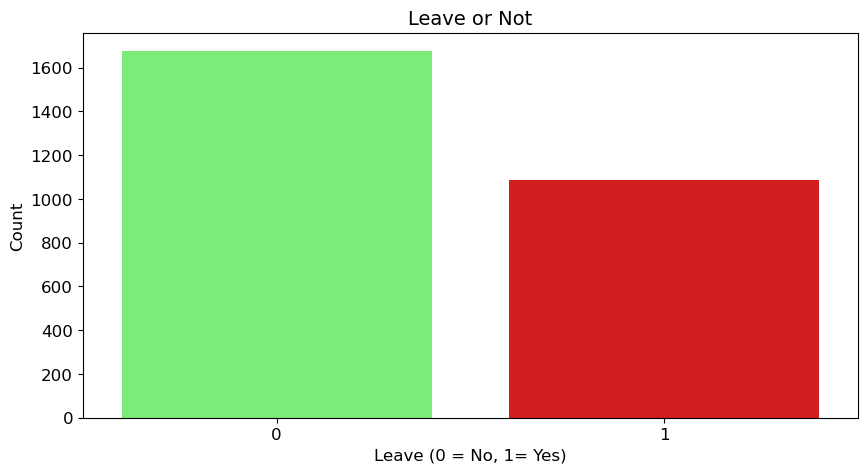

In [37]:
import seaborn as sns
plt.figure(figsize=(10,5))
plt.title('Leave or Not', fontsize=14)
sns.countplot(x="LeaveOrNot", data=emp, palette=('#66FF66','#F00000'))
plt.xlabel("Leave (0 = No, 1= Yes)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

Il numero di dipendenti che non lascia il proprio posto di lavoro è maggiore di coloro che decidono di andare via. Tuttavia, la differenza non risulta essere eccessivamente elevata tale da compromettere i risultati ottenuti sul dataset originale. 

## 1. Analisi univariata: 
Mostra la distribuzione dei valori delle singole variabili esplicative.

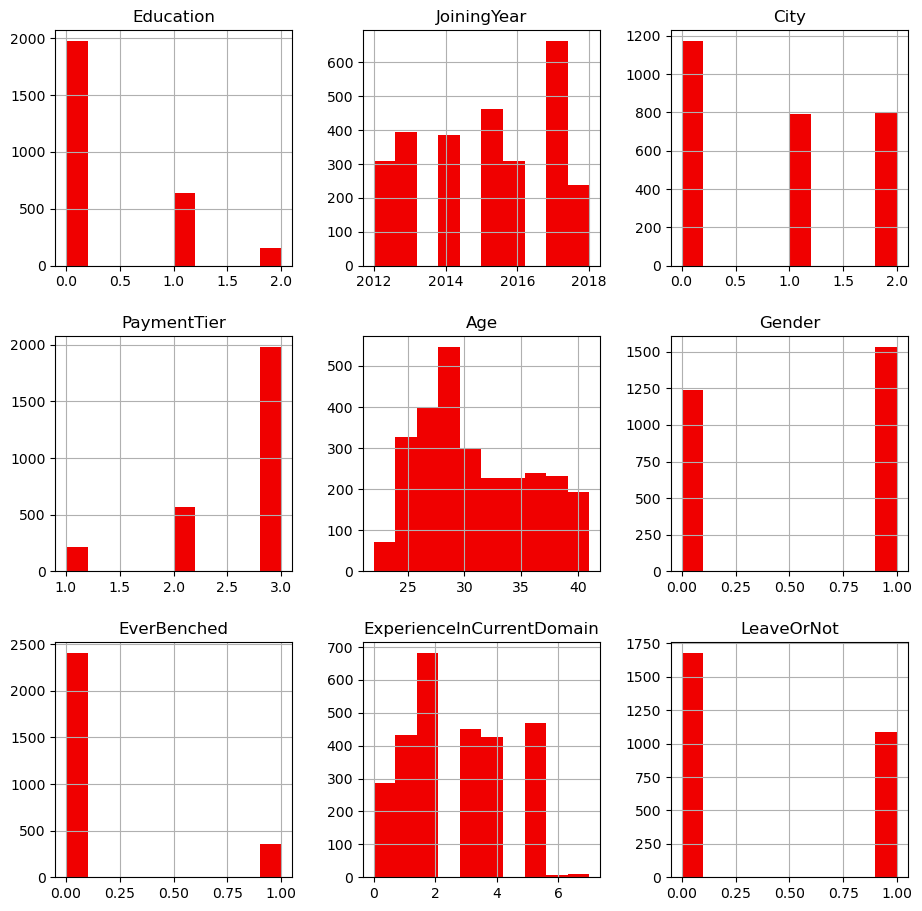

In [44]:
emp.hist(figsize = (11,11), color="#F00000");
plt.show()

Dagli istogrammi è possibile 
dedurre che:
1) Molti tra i dipendenti possiedono una laurea triennale (Bachelor's Degree);
2) Vi è stato un picco di assunzioni intorno al 2017;
3) Più dipendenti provengono da Bangalore (in India);
4) Più della metà dei dipendenti appartiene alla categoria salariale più elevata;
5) La moda associata all'età dei dipendenti si aggira attorno ai 27-30 anni;
6) Lavorano in azienda più uomini che donne;
7) La maggior parte dei dipendenti non è mai stato privato o escluso da un incarico;
8) Molti dipendenti hanno un numero di anni di esperienza nello stesso settore di riferimento in cui lavorano, pari a 2;
9) Come è stato già detto, il numero di dipendenti che lasciano l'azienda è inferiore a coloro che decidono di restarvi. 

## 2. Analisi bivariata: 
Mostra la relazione esistente tra la variabile target (LeaveOrNot) e le singole variabile indipendenti, una ad una.

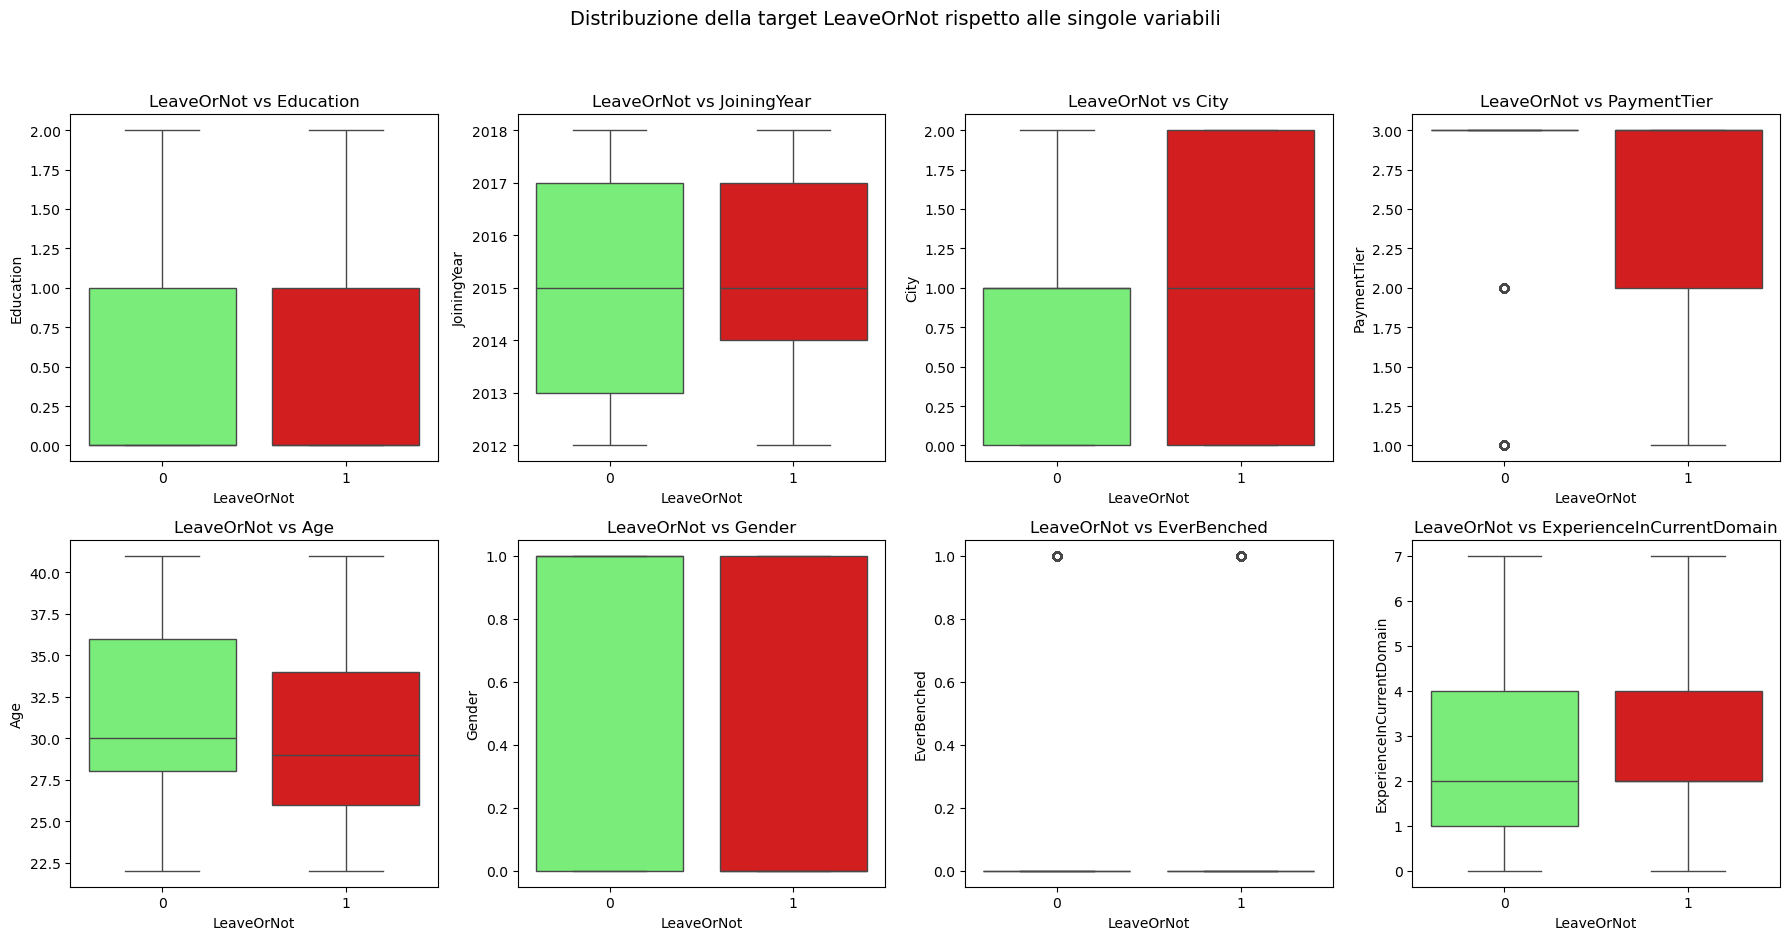

In [48]:
fig,axes=plt.subplots(2,4,figsize=(18,12))
fig.suptitle('Distribuzione della target LeaveOrNot rispetto alle singole variabili', fontsize=14)
features=['Education','JoiningYear','City','PaymentTier','Age','Gender','EverBenched','ExperienceInCurrentDomain']

for i,feature in enumerate(features):
    row,col=divmod(i,4) # row=i//4 , col=i%4
    sns.boxplot(
        ax=axes[row,col],
        x=emp['LeaveOrNot'],
        y=emp[feature],
        hue=emp['LeaveOrNot'],
        palette=('#66FF66','#F00000')
    )
    axes[row,col].set_title(f'LeaveOrNot vs {feature}', fontsize=12)
for ax in axes.flatten():
    ax.legend_.remove()
plt.tight_layout(rect=[0,0.2,1,0.95])
plt.show()

Concentriamoci sull'analisi delle variabili che apparentemente presentano una maggiore influenza sulla target:
1. **LeaveOrNot vs JoiningYear**: il range di anni in cui i dipendenti decidono di rimanere in azienda, risulta più ampio e collocato tra il 2013 ed il 2017, al contrario di coloro che vanno via la cui maggioranza sembrerebbe essere stata assunta tra il 2015 e il 2017;
2. **LeaveOrNot vs City**: vi è netta differenza tra i due gruppi e la città di appartenenza sembra essere un predittore significativo nella decisione di lasciare l'azienda: coloro che abbandonano il proprio lavoro sembrano avere una maggior eterogeneità sulla città in cui sono stabiliti, mentre coloro che rimangono sono più concentrati tra Bangalore e Nuova Delhi;
3. **LeaveOrNOt vs PaymentTier**: chi rimane tende ad avere stabilmente un salario più alto mentre chi lascia tende a percepire una minore retribuzione seppur collocata ad un livello alto;
4. **LeaveOrNot vs Age**: coloro che lasciano il posto di lavoro sono più giovani di coloro che decidono di rimanere;
5. **LeaveOrNot vs ExperienceInCurrentDomain**: chi lascia il posto di lavoro sembrerebbe avere un numero di anni di esperienza maggiori rispetto a chi rimane, nel settore di riferimento.

Abbiamo deciso di mantenere tutte e 8 le variabili in quanto, non essendo il dataset eccessivamente ampio e avendo già rimosso tutti i duplicati, l'eliminazione di ulteriori dati avrebbe potuto aumentare il rischio di ottenere risultati falsati e poco verosimili.

Inoltre, i box plot danno una visione generale della distribuzione dei dati e non informazioni sulla correlazione effettiva tra le variabili esplicative e la target o sulla frequenza e dimensione dei due gruppi. 
Per questo motivo potrebbero esserci delle apparenti contraddizioni rispetto ai seguenti risultati dell'analisi multivariata: 

## 3. Analisi multivariata:
Permette di analizzare contemporaneamente la correlazione esistente tra le varie features e tra queste ultime e la variabile target.

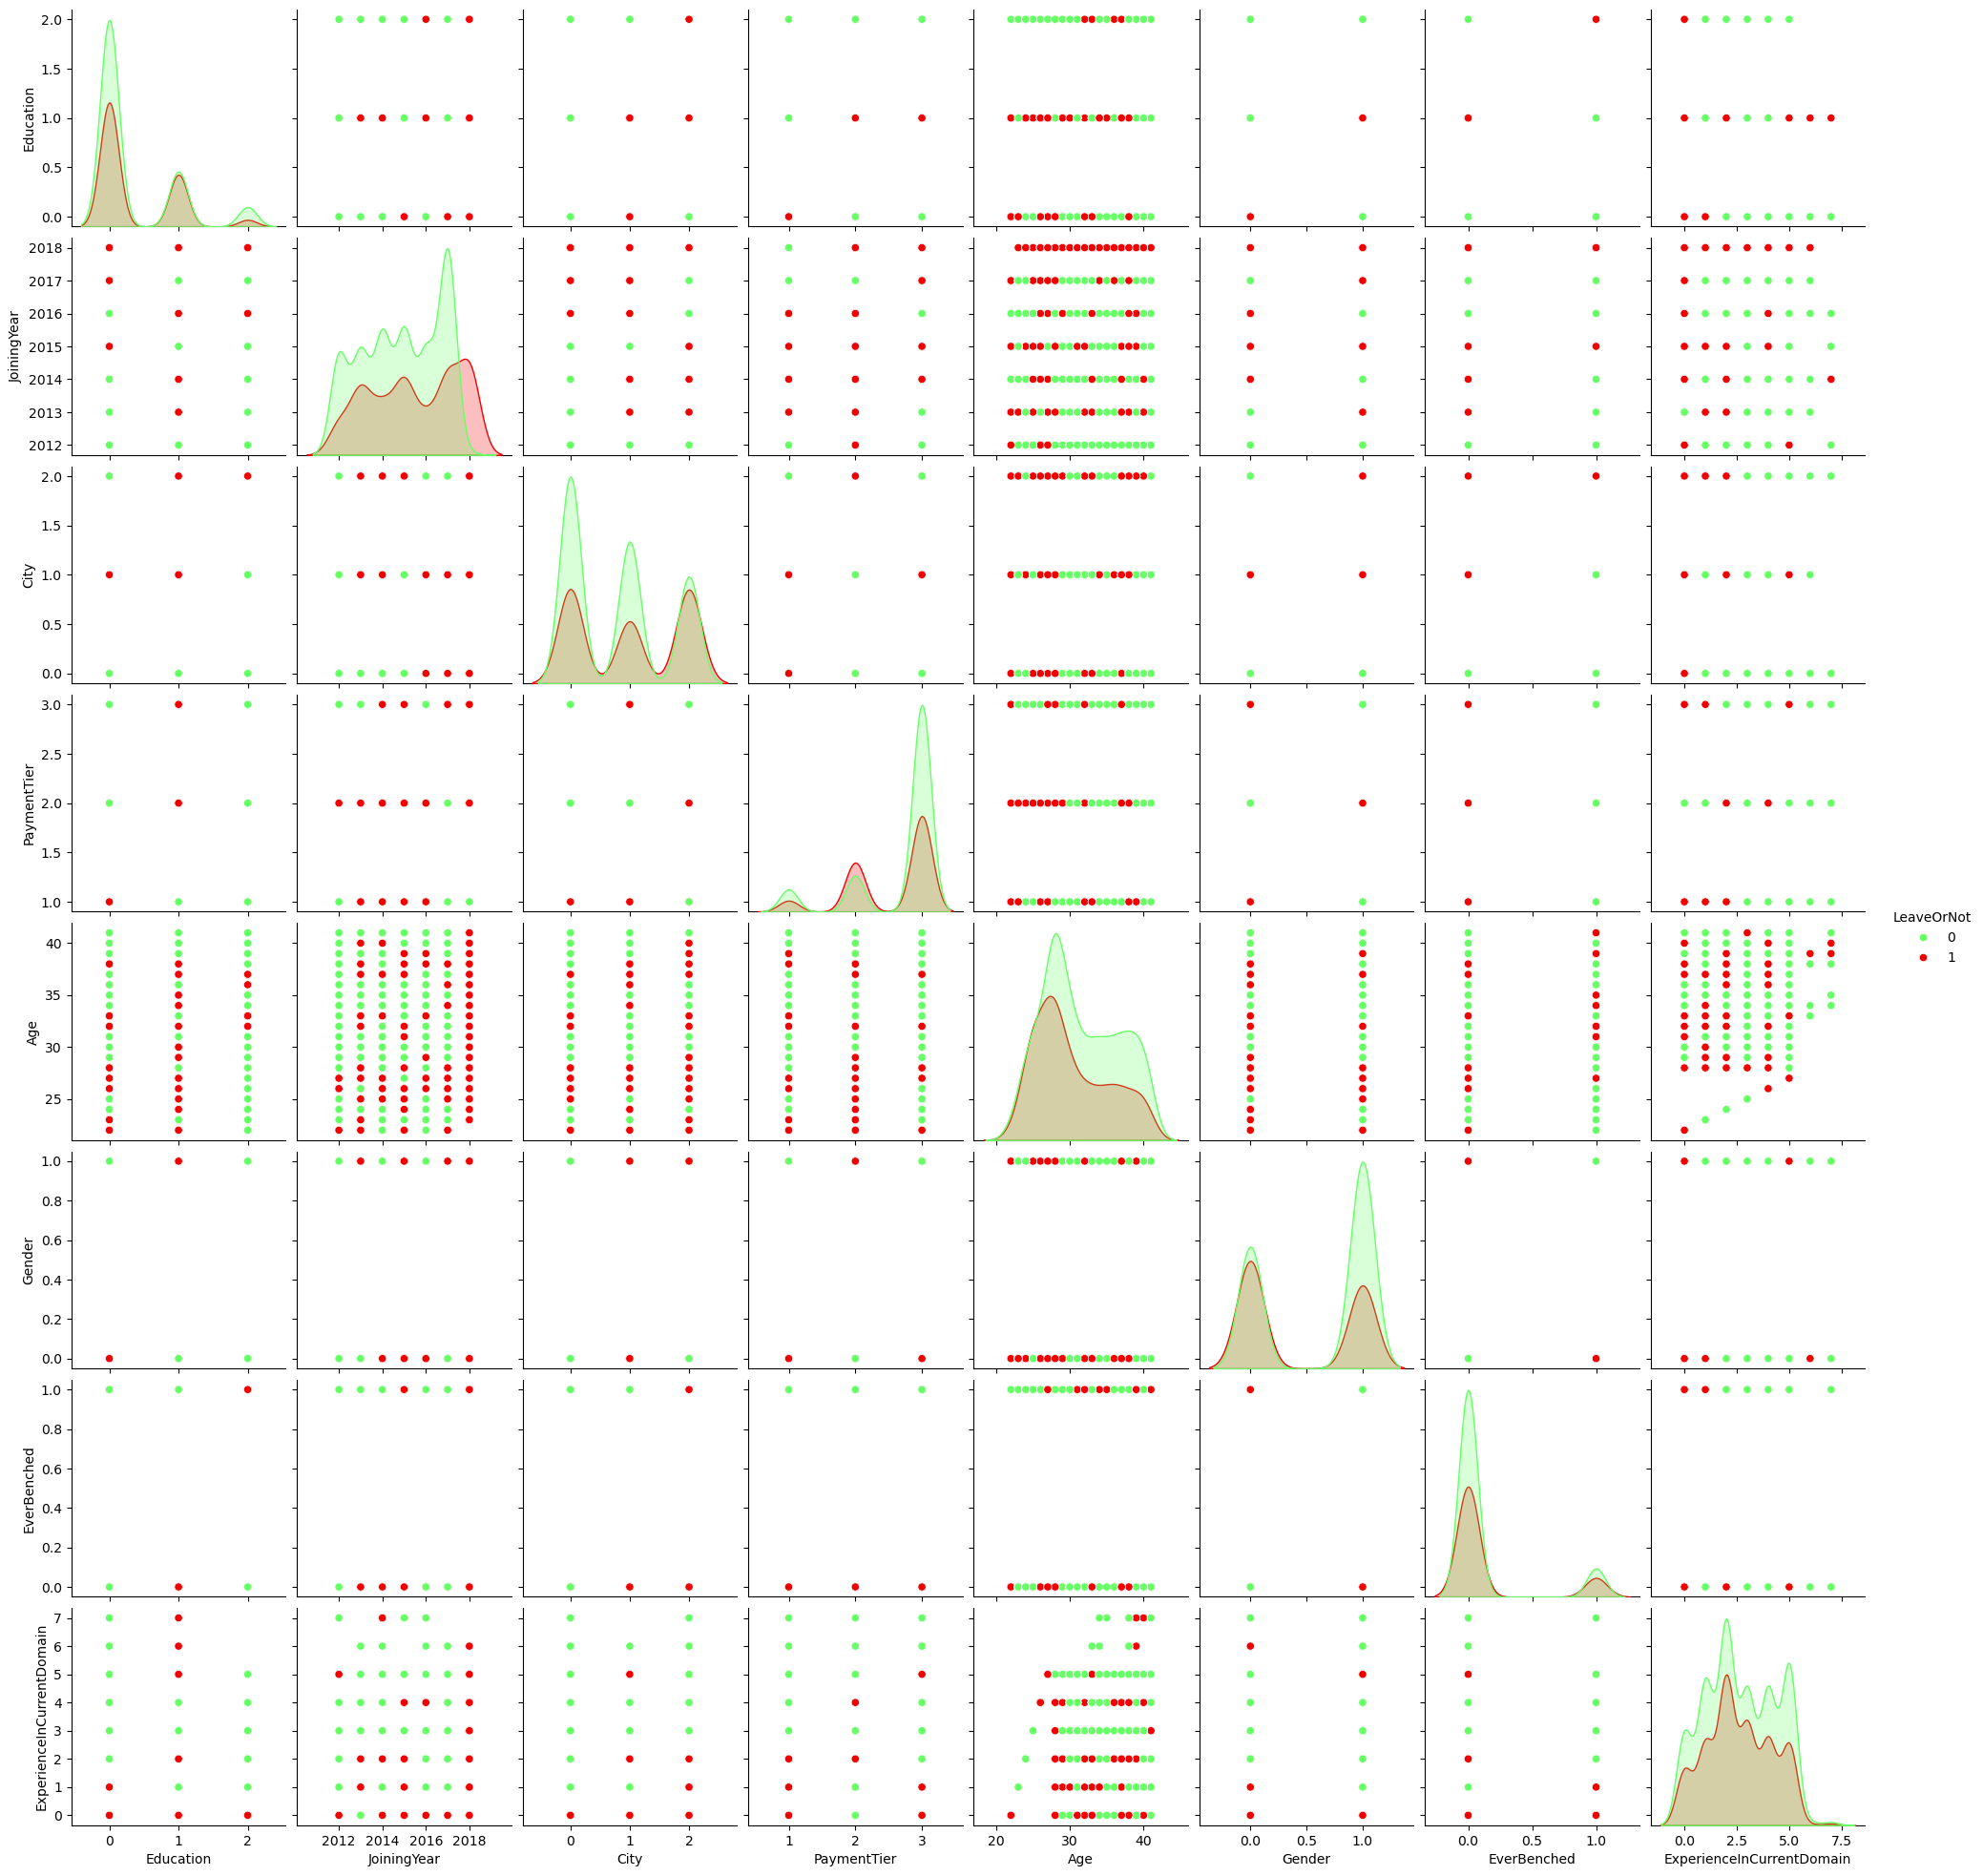

In [46]:
sns.pairplot(emp, hue='LeaveOrNot', palette=('#66FF66', '#F00000'));
plt.show()

1. **Education**: Coloro che lasciano il posto di lavoro sono principalmente in possesso di un titolo di studi di grado inferiore rispetto a coloro che decidono di rimanere;
2. **JoiningYear**: Chi è stato assunto più recentemente tende a non lasciare il proprio posto di lavoro;
3. **City**: Chi non lascia proviene principalmente da Bengaluru e Nuova Delhi, mentre la differenza è più sottile e meno evidente per coloro che provengono da Pune;
4. **PaymentTier**: Coloro che hanno un maggior livello salariale tendono a non lasciare il proprio posto di lavoro;
5. **Age**: Chi decide di lasciare è più giovane rispetto a coloro che rimangono;
6. **Gender**: mentre nel genere femminile la differenza tra chi lascia e decide di rimanere è sottile, nel maschile sono maggiori i casi di chi rimane;
7. **EverBenched**: per coloro che sono stati privati almeno una volta di un incarico, la differenza tra chi lascia e chi rimane è più bassa; invece per chi non ha mai perso il proprio incarico, la frequenza di chi rimane è più alta rispetto a chi va via;
8. **ExperienceInCurrentDomain**: In generale, all'aumentare degli anni di esperienza nel proprio settore lavorativo, i dipendenti tendono a mantenere il proprio incarico.

Attraverso la Heatmap (mappa di calore) siamo in grado di osservare l'intensità del legame esistente tra tutte le variabili sulla base della correlazione.

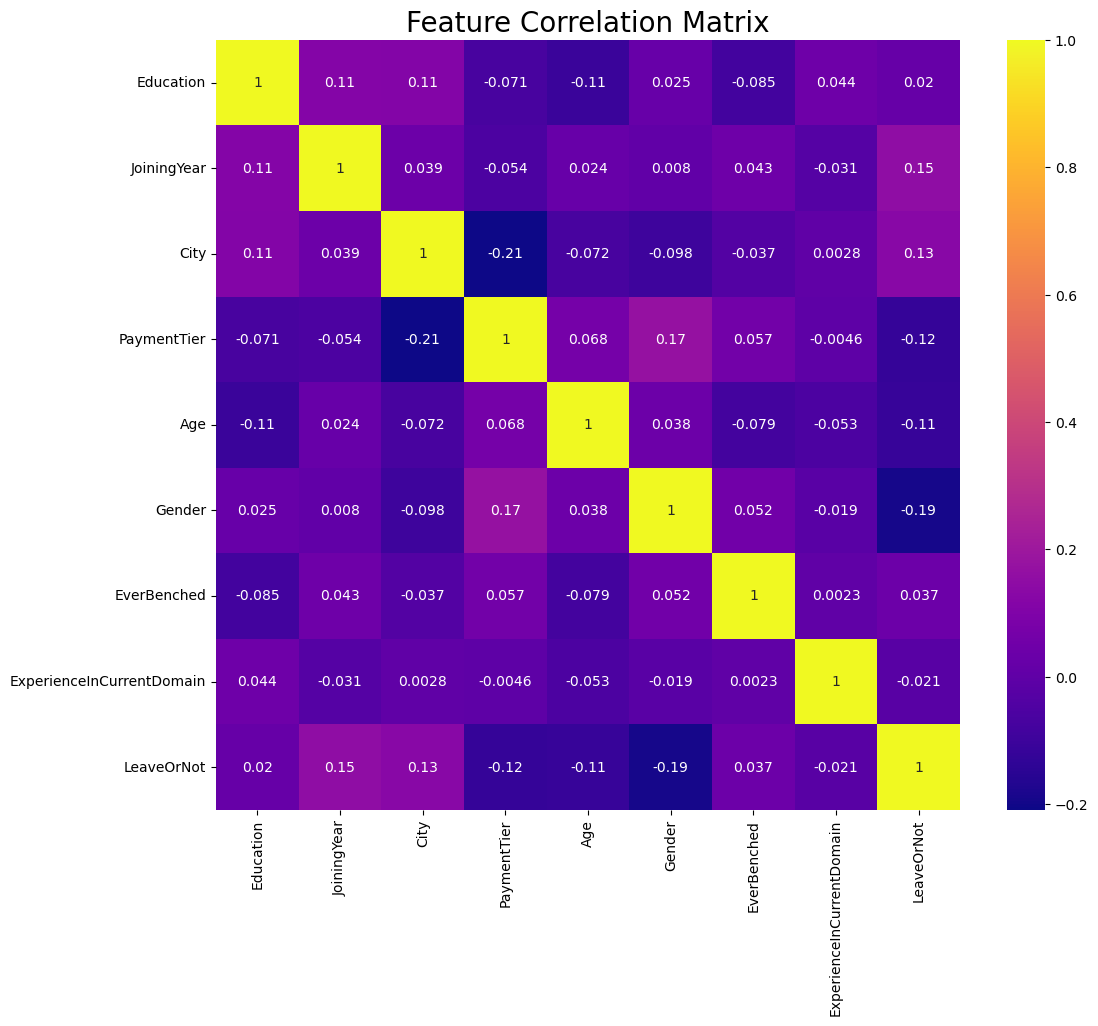

In [124]:
plt.figure(figsize=(12,10))
sns.heatmap(emp.corr(), annot=True, cmap='plasma')
plt.title("Feature Correlation Matrix",fontsize=20)
plt.show()

Come si può notare dalla matrice, tra tutte le variabili del dataset, quelle che presentano una correlazione maggiore (ma comunque bassa) sono:
* Gender e Payment Tier (0.17);
* Leave Or Not e Joining Year (0.15);
* Leave Or Not e City (0.13).

# FASE 2: ADDESTRAMENTO DEI MODELLI DI MACHINE LEARNING

Prima di procedere con l'addestramento dei singoli modelli, è necessario suddividere il dataset in questione in due sottodataset e standardizzare i dati:
* **Training set**: su cui si effettua l'addestramento del modello;
* **Test Set**: che costituisce un insieme di dati mai visti dal modello e su cui si calcolano le predizioni e le successive metriche di valutazione.

In [49]:
#Dividiamo i dati in x (features) e y (variabile target)
from sklearn.model_selection import train_test_split

x=emp.drop(['LeaveOrNot'], axis=1)
y=emp['LeaveOrNot']

In [51]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [53]:
from sklearn.preprocessing import StandardScaler

# Standardizzazione
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Per ciascuno dei quattro modelli di apprendimento impiegati nell’analisi, abbiamo sviluppato un codice che consente di:

1. Addestrare il modello sui dati disponibili;
2. Successivamente, valutare le prestazioni di ogni modello attraverso l’utilizzo di metriche chiave come l’accuratezza (accuracy), il punteggio F1 (F1 score) e la matrice di confusione, al fine di ottenere un quadro completo della capacità predittiva di ciascun algoritmo.
3. Infine, per facilitare l’interpretazione dei risultati e comprendere meglio la distribuzione dei dati, è stata applicata una tecnica di riduzione della dimensionalità: **l’Analisi delle Componenti Principali (PCA)**, un algoritmo di apprendimento non supervisionato. Poichè il dataset contiene 8 variabili (features) e una variabile target, risulta complesso rappresentare graficamente le regioni decisionali in uno spazio a così alta dimensionalità. La PCA, infatti, permette di superare questa difficoltà, proiettando i dati in uno spazio bidimensionale in cui viene preservata la maggior parte della varianza informativa originale. Questo approccio consente una visualizzazione più chiara e intuitiva del comportamento del modello di classificazione, pur trattandosi di una rappresentazione semplificata rispetto allo spazio delle caratteristiche completo.

In [65]:
from sklearn.decomposition import PCA

# PCA (riduzione a 2 dimensioni)
pca=PCA(n_components=2, random_state=42)
x_train_pca=pca.fit_transform(x_train_scaled)
x_test_pca=pca.transform(x_test_scaled)

In [67]:
componenti = pd.DataFrame(pca.components_, columns=x.columns, index=['PC1', 'PC2'])
print(componenti)

     Education  JoiningYear      City  PaymentTier       Age    Gender  \
PC1  -0.353358    -0.189072 -0.534555     0.548828  0.282060  0.391086   
PC2   0.407290     0.250926 -0.053019     0.168244 -0.481466  0.366663   

     EverBenched  ExperienceInCurrentDomain  
PC1     0.139487                  -0.021593  
PC2     0.505521                   0.343848  


La visualizzazione della matrice di correlazione tra le componenti principali aiuta a comprendere come queste siano le risultanti di una combinazione tra varie features in quanto con nessuna di esse vi è un rapporto di correlazione così alto da poter rappresentare unicamente queste ultime. 
* La PC1, infatti, può essere considerata come una combinazione tra la variabile "City", "Gender" e "Payment Tier", mentre la PC2 come una combinazione tra la variabile "Age", "Education" e "Ever Benched". 

In [70]:
x_train.shape, y_train.shape

((1934, 8), (1934,))

In [72]:
x_test.shape, y_test.shape

((830, 8), (830,))

Per poter visualizzare graficamente il risultato del processo di classificazione è necessario definire una classe (plot_decision_region). In particolare questa visualizzazione consente di comprendere come il modello separa le diverse classi generando una griglia di punti e disegnando le rispettive aree di appartenenza. 
Nei grafici a seguire la classe 0 (dipendenti che restano) è rappresentata dall'area Verde, mentre la classe 1 (dipendenti che vanno via) dall'area Rossa.

In [77]:
from matplotlib.colors import ListedColormap
# Funzione per il plot dei dati
def plot_decision_regions(X, y, classifier, title):
    cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
    cmap_bold = ['#FF0000', '#00FF00']

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=ListedColormap(cmap_bold))
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    plt.title(title)
    plt.show()


# 1. Regressione Logistica con Polynomial Feature Mapping:

Il primo modello di classificazione binaria e lineare che è stato implementato è la **Regressione Logistica** che assegna le etichette della variabile target (0 o 1) alle singole features sulla base della probabilità di appartenenze ad esse. Poichè il dataset della nostra analisi non è linearmente separabile, estendiamo l'implementazione del classificatore di regressione logistica anche a un caso non lineare, tramite la Polynomial Feature Mapping o Feature Expansion. Questa modalità ci permette di proiettare i dati in uno spazio a maggiore dimensionalità (nel nostro caso tridimensionale) al fine di ottenere una divisione più efficiente degli esempi nelle classi. Il codice si occupa di addestrare il modello sui dati di training, valutarne le performance e successivamente utilizzarlo per effettuare previsioni sui dati di test.

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score,f1_score
from sklearn.pipeline import make_pipeline

pipe_lr = make_pipeline(PolynomialFeatures(degree=3),StandardScaler(),
                        LogisticRegression(C=10,random_state=42, max_iter=1000))
pipe_lr.fit(x_train, y_train)
y_pred=pipe_lr.predict(x_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7301204819277108
F1 Score: 0.5805243445692884
Confusion Matrix:
 [[451  52]
 [172 155]]
Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.90      0.80       503
           1       0.75      0.47      0.58       327

    accuracy                           0.73       830
   macro avg       0.74      0.69      0.69       830
weighted avg       0.73      0.73      0.71       830



Al fine di sintetizzare le performance che otteniamo dall'applicazione del modello sul dataset scelto, utilizziamo un 'Classification Report' 
che ci restituisce delle metriche sia globali sia per classi; quest'ultimo punto è fondamentale poichè, essendo il dataset considerato non perfettamente bilanciato, è necessario non limitarsi all'interpretazione delle metriche globali.
Vediamole una ad una.

Relativamente alla classe 0:
* ⁠Precision (Classe 0): 0.72. Questo significa che il 72% delle istanze predette come appartenenti alla classe 0 erano effettivamente corrette.
* ⁠Recall (Classe 0): 0.90. Il 90% delle istanze che appartenevano effettivamente alla classe 0 sono state correttamente identificate dal modello. Quindi, il modello riesce a trovare il 90% di tutte le istanze di classe 0 presenti nel dataset.
* ⁠F1-score (Classe 0): 0.80. Questa è la media armonica tra precision e recall, che ci fornisce un singolo valore che bilancia entrambe le metriche; quindi un F1-score all'80% ci testimonia buone prestazioni sia in termini di precision che di recall.
* ⁠Support (Classe 0): 503, è il numero di istanze della classe 0 presenti nel dataset di test.

Le stesse interpretazioni valgono per i valori della classe 1:
* ⁠Precision (Classe 1): 0.75.
* ⁠Recall (Classe 1): 0.47.
* ⁠F1-score (Classe 1): 0.58.
* Support (Classe 1): 327.

Possiamo quindi concludere che il modello sembra avere prestazioni leggermente migliori sulla classe 0 rispetto alla classe 1. 
La classe 0, infatti, ha una precision e un recall più elevati, indicando che il modello è più bravo a identificare correttamente le istanze di questa classe.

L'accuracy complessiva del 73% è discreta, ma c'è ancora margine di miglioramento, soprattutto per la classe 1.


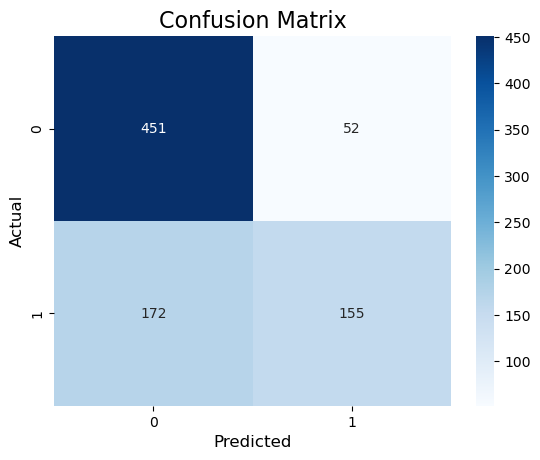

In [72]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)  
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

In estrema sintesi, le performance ottenute dal modello possono essere rappresentate graficamente dalla precedente Confusion Matrix. Assumendo che la classe con etichetta 0 sia la classe "Leave Not" e la classe con etichetta 1 sia la classe "Leave", i dati sono stati classificati come:

* 451 true positives: dati appartenenti alla classe 0 e classificati come 0
* 172 false positives: dati appartenenti alla classe 1 ma classificati come 0
* 52 false negatives: dati appartenenti alla classe 0 ma classificati come 1
* 155 true negatives: dati appartenenti alla classe 1 e classificati come 1

Quindi, il modello classificata erroneamente un totale di 224 esempi -> **ERROR RATE = 26,99%**

A questo punto, plottiamo il grafico rappresentativo delle regioni decisionali per completare il processo di Data Visualization. Per farlo è necessario considerare due sole features che, come abbiamo detto in precedenza, possiamo ricavare dall'applicazione della PCA. I dati vengono distinti nelle due regioni decisionali in base alla PC1 e PC2, rispettivamente collocate sull'asse x e y.

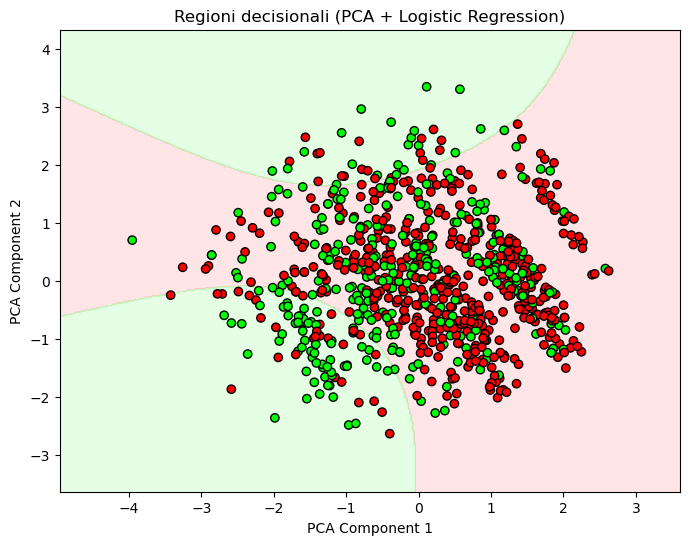

In [75]:
# Modello
pipe_lr.fit(x_train_pca, y_train)

# Esegui il plot
plot_decision_regions(x_test_pca, y_test.values, pipe_lr, "Regioni decisionali (PCA + Logistic Regression)")

Vediamo come un *confine decisionale non lineare*, ottenuto grazie all'implementazione della Feature Mapping nel modello, permette
di cogliere la complessità dei dati. 
Per ottenere una miglior suddivisione visiva dei punti nelle aree di classificazione potremmo provare ad aumentare il grado del polinomio applicato al modello, ottenendo così dei confini decisionali più complessi.
E' necessario però prestare attenzione a identificare il giusto trade off tra regioni decisionali complesse e l'oneroso calcolo che esse comportano; ciò è possibile, come vedremo in fase finale, tramite l'ottimizzazione dell'iperparametro degree.

# 2. SVM con Kernel

Le Support Vector Machines (SVM) sono algoritmi di apprendimento supervisionato che individuano l'iperpiano ottimale per separare classi di dati, massimizzando il margine, ovvero la distanza tra i punti più vicini (vettori di supporto) e l'iperpiano separatore. In contesti non linearmente separabili le SVM sfruttano funzioni kernel, che con il kernel trick, offrono la possibilità di calcolare il prodotto scalare interno tra due future maps nello spazio originale, evitando così di calcolarlo in spazi a dimensionalità estremamente elevata che potrebbe risultare complesso e oneroso. 


In [107]:
from sklearn.svm import SVC

# scaler=StandardScaler()
# x=scaler.fit_transform(x)

svm=SVC(kernel='rbf', probability= True, random_state=42, gamma=0.1, C=100)
svm.fit(x_train_scaled, y_train)
y_pred=svm.predict(x_test_scaled)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7987951807228916
F1 Score: 0.7065026362038664
Confusion Matrix:
 [[462  41]
 [126 201]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.92      0.85       503
           1       0.83      0.61      0.71       327

    accuracy                           0.80       830
   macro avg       0.81      0.77      0.78       830
weighted avg       0.80      0.80      0.79       830



Classe 0:

* Precision (0.79): Il 79% delle volte in cui il modello predice la classe 0, la predizione è corretta. Questo significa che circa il 21% delle predizioni di classe 0 sono in realtà errori (falsi positivi).
* Recall (0.92): Il modello riesce a riconoscere correttamente il 92% dei campioni che appartengono realmente alla classe 0. Solo l'8% dei veri campioni di classe 0 viene classificato erroneamente come classe 1 (falsi negativi).
* F1-score (0.85): Un valore di 0.85 indica un buon equilibrio tra la capacità del modello di riconoscere la classe 0 e la precisione delle sue predizioni per questa classe.

Support (503): Indica che nel dataset di test ci sono 503 campioni appartenenti alla classe 0.

Classe 1:

* Precision (0.83): L'83% delle volte in cui il modello predice la classe 1, la predizione è corretta. Quindi, il modello commette errori (falsi positivi) nel 17%% delle predizioni di classe 1.
* Recall (0.61): Il modello riesce a riconoscere correttamente solo il 61% dei campioni che appartengono realmente alla classe 1. Questo significa che poco meno della metà dei veri campioni di classe 1 viene classificata erroneamente come classe 0 (falsi negativi).
* F1-score (0.71): L’F1-score di 0.71 indica che, per la classe 1, il modello ha una performance piuttosto bassa, dovuta soprattutto al recall molto basso.

Support (327): Indica che nel dataset di test ci sono 327 campioni appartenenti alla classe 1.

L’accuracy complessiva del modello è circa 0.79. Questo valore indica che il modello classifica correttamente il 79% dei campioni totali. Tuttavia, considerando lo sbilanciamento tra precision e recall nelle due classi, l’accuracy da sola non è sufficiente a descrivere la bontà del modello che tende a favorire la classe 0 rispetto alla classe 1, come evidenziato dal recall molto più basso per la classe 1. In presenza di classi sbilanciate è fondamentale considerare anche precision, recall e F1-score, non solo l’accuracy.

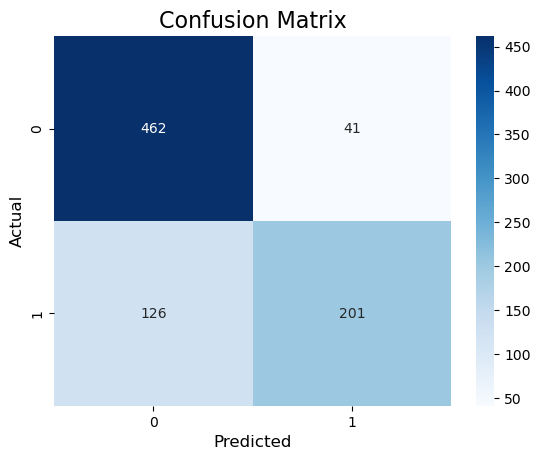

In [83]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)  
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

La matrice di confusione mostra che:

* 462 true positives: dati appartenenti alla classe 0 e classificati come 0
* 126 false positives: dati appartenenti alla classe 1 ma classificati come 0
* 41 false negatives: dati appartenenti alla classe 0 ma classificati come 1
* 201 true negatives: dati appartenenti alla classe 1 e classificati come 1

Quindi, il modello classificata erroneamente un totale di 167 esempi -> **ERROR RATE = 20,13%** 

L'errore generale è inferiore a quello rilevato nella Regressione Logistica con Feature Mapping.

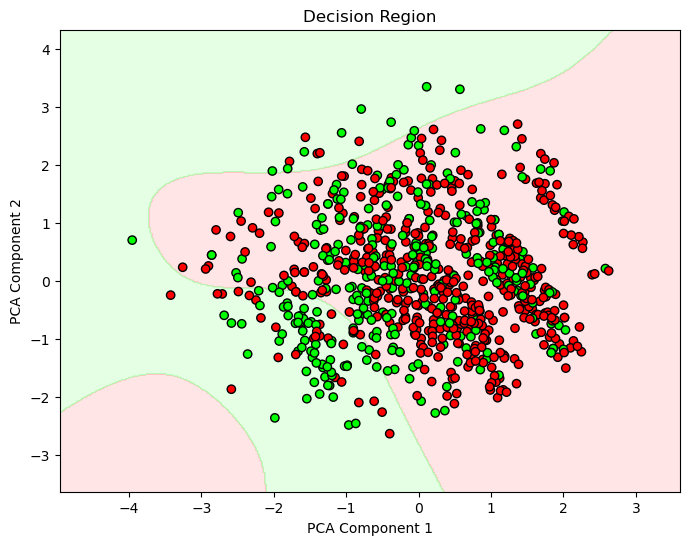

In [88]:
svm_pca=SVC(kernel='rbf', random_state=42, gamma=0.1, C=100)
svm_pca.fit(x_train_pca, y_train)

plot_decision_regions(x_test_pca, y_test.values, svm_pca, 'Decision Region')

Sono presenti diversi punti verdi (classe 0) all’interno della regione rossa (predetta come classe 1) e viceversa. Questo riflette la difficoltà del modello nel distinguere perfettamente le due classi, come già evidenziato dai valori di precision e recall, soprattutto per la classe 1.

# 3. Albero Decisionale

Il **decision tree** è un modello di apprendimento supervisionato, ed in particolare di classificazione, che ha l'obiettivo di assegnare le labels ai vari esempi del dataset sulla base delle domande poste al modello e delle risposte ottenute. 
Possiamo individuare:
1. La **struttura decisionale**: a partire dalla radice dell'albero, l'algoritmo pone delle domane e in base alle risposte fornite e sulla base di un criterio di maggioranza, assegna le etichette della target;
2. **Modello di suddivisione**: l'algoritmo suddivide i vari rami in base alla caratteristica che massimizza il guadagno informativo, ovvero la riduzione dell'impurità quando si passa dal nodo padre al nodo figlio.
Tra le varie misure di impurità che possono essere utilizzate, abbiamo scelto l'**Indice di Gini**, che fornisce la frequenza con cui un esempio potrebbe essere classificato come errato. Esso assume valore minimo, **pari a 0**, quando tutti gli elementi appartengono ad un unica classe e non vi è probabilità di classificarli come errati; assume valore massimo, **pari a 1**, quando tutti gli elementi sono distribuiti equamente tra le classi. 

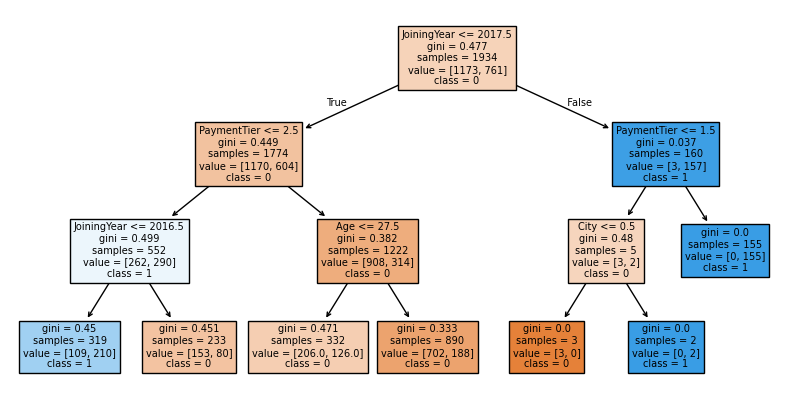

In [85]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
tree = DecisionTreeClassifier(criterion='gini',
                              max_depth=3, random_state=42)

tree.fit(x_train, y_train)
y_pred=tree.predict(x_test)
feature_names= x.columns[:]
class_names=np.unique(y_train).astype(str)

# Visualizzazione dell'albero di decisione
plt.figure(figsize=(10,5))
plot_tree(tree, filled=True, feature_names=feature_names, class_names=class_names)
plt.show()

1. **Radice (JoiningYear <= 2017.5)**: Il primo split avviene sull’anno di assunzione: i dipendenti assunti prima della seconda metà del 2017 vengono maggiormente classificati come coloro che rimangono (classe 0), mentre quelli assunti dopo vengono tendenzialmente classificati come a rischio di abbandono (classe 1).
Questo suggerisce che la stabilità aziendale aumenta con l’anzianità lavorativa.

2. **Ramo sinistro (JoiningYear <= 2017.5 → True)**: Successivamente, viene considerato il PaymentTier (<= 2.5). Un livello salariale più basso (ma non troppo) corrisponde a una maggiore probabilità di lasciare l’azienda specialmente nei casi in cui l'assunzione è avvenuta tra il 2016 e il 2017. Chi invece ha un salario alto viene classificato come classe 0 (dipendenti che decidono di rimanere).

3. **Ramo destro (JoiningYear <= 2017.5 → False)**: Qui troviamo:
    PaymentTier <= 1.5: chi ha salari >= 1,5 (medio bassi) viene classificato come a rischio di abbandono (classe 1) con gini prossimo a zero, quindi     con grande certezza.
    Tra coloro con salari bassi, viene usata la variabile City: chi vive a Nuova Delhi o Bengalore (City <= 0.5) tende a rimanere, mentre chi vive a Bangalore e Pune (City > 0.5) abbandona con probabilità molto alta. A Bangalore la classificazione non è molto netta.

In [88]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('F1 Score:', f1_score(y_test, y_pred))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('Classification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.7421686746987952
F1 Score: 0.5946969696969697
Confusion Matrix:
 [[459  44]
 [170 157]]
Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.91      0.81       503
           1       0.78      0.48      0.59       327

    accuracy                           0.74       830
   macro avg       0.76      0.70      0.70       830
weighted avg       0.75      0.74      0.73       830



Le performance dell'albero decisionale, pari al 74,2% di **Accuracy**, sono buone; ciò vuol dire che classifica correttamente 616 elementi su 830 (del test set). Essendo un dataset sbilanciato, l'F1 score non risulta particolarmente alto per la classe 1. 

La **Precision** mostra che appartengono realmente alla classe 0, tra tutti quelli classificati come tali, il 73% dei soggetti e come classe 1, il 78%. 

La **Recall**, invece, mostra che vengono classificati correttamente tra tutti quelli realmente facenti parte della classe 0, il 91% degli elementi, mentre come classe 1 solo il 48%: il modello non riesce a classificare correttamente molti soggetti che decidono di lasciare l'azienda. È un problema dovuto allo sbilanciamento del dataset. 

Tutto ciò può essere osservato meglio nella matrice di confusione illustrata di seguito:

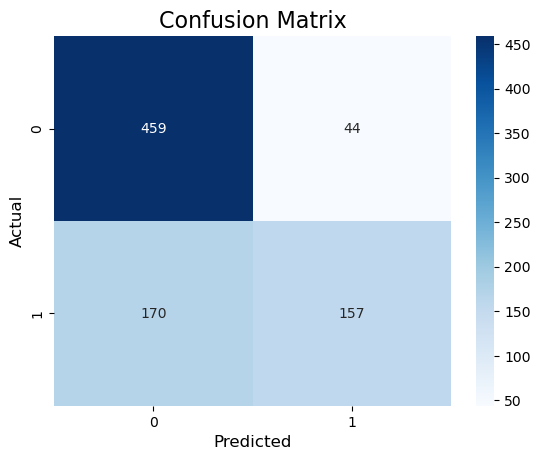

In [164]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)  
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

Anche in questo caso le performance ottenute dal modello possono essere rappresentate graficamente dalla Confusion Matrix. Assumendo che la classe con etichetta 0 sia la classe "positiva" e la classe con etichetta 1 sia la classe "negativa", i dati sono stati classificati come:

* 459 true positives: dati appartenenti alla classe 0 e classificati come 0
* 170 false positives: dati appartenenti alla classe 1 ma classificati come 0
* 44 false negatives: dati appartenenti alla classe 0 ma classificati come 1
* 157 true negatives: dati appartenenti alla classe 1 e classificati come 1 

Quindi, il modello classificata erroneamente un totale di 214 esempi -> **ERROR RATE = 25,78%** (Maggiore del SVM ma minore della Regressione Logistica).

Plottiamo il grafico rappresentativo delle regioni decisionali per completare il processo di Data Visualization, attraverso la PCA:

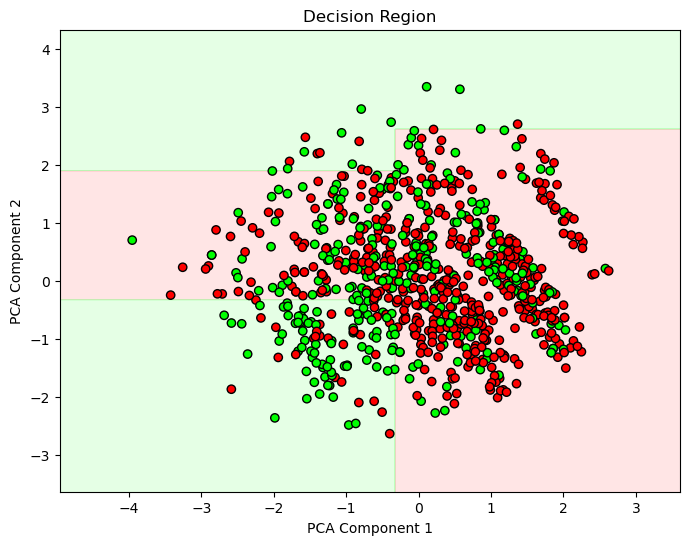

In [166]:
tree_pca= DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
tree_pca.fit(x_train_pca, y_train)

plot_decision_regions(x_test_pca, y_test.values, tree_pca, 'Decision Region')

Il modello dell'albero decisionale, differentemente dai precedenti, individua regioni decisionali a blocchi delineati da rette e non da linee curve. I confini decisionali sono abbastanza lineari e ciò è dovuto ad un basso livello di profondità dell'albero (depth).

# 4. AdaBoost

**AdaBoost** è un algoritmo di boosting (apprendimento sequenziale) che combina classificatori "deboli" in un modello forte. A ogni iterazione, aumenta il peso degli esempi mal classificati, spingendo i classificatori successivi a correggere gli errori precedenti. La previsione finale è una media ponderata delle singole ipotesi, con pesi determinati dall'accuratezza di ciascun classificatore. 
**Random Forest** è un metodo di ensamble learning basato su bagging (apprendimento in parallelo), che costruisce una "foresta" di alberi decisionali addestrati su sottoinsiemi casuali di dati e feature. Ciascun albero si costruisce a partire da una campione di set di dati e ad ognuno di essi viene assegnato un sottoinsieme casuale di attributi per evitare che tutti gli alberi utilizzino le medesime caratteristiche. La previsione finale sarà data dalla media delle singole previsioni (regressione) o dalla classe maggiormente votate dagli alberi stessi (classificazione).
L’utilizzo di AdaBoost con Random Forest come base learner rappresenta un approccio ibrido che combina due paradigmi di ensamble learning: il boosting (AdaBoost) e il bagging (Random Forest). Questa sinergia mira a sfruttare i punti di forza di entrambi gli algoritmi.

In [71]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
ada = AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
ada.fit(x_train, y_train)
y_pred = ada.predict(x_test)
print(ada.score(x_test, y_test))
print(classification_report(y_test, y_pred))

0.7686746987951807
              precision    recall  f1-score   support

           0       0.74      0.95      0.83       503
           1       0.87      0.48      0.62       327

    accuracy                           0.77       830
   macro avg       0.81      0.72      0.73       830
weighted avg       0.79      0.77      0.75       830



Le performance di AdaBoost, pari al 76,86% di Accuracy, sono buone; ciò vuol dire che classifica correttamente circa il 77% degli elementi (del test set).

La Precision mostra che appartengono realmente alla classe 0, tra tutti quelli classificati come tali, il 74% dei soggetti e come classe 1, l'87%.

La Recall, invece, mostra che vengono classificati correttamente tra tutti quelli realmente facenti parte della classe 0, il 95% degli elementi, mentre come classe 1 solo il 48%: anche in questo caso, il modello non riesce a classificare correttamente molti soggetti che decidono di lasciare l'azienda. È un problema dovuto allo sbilanciamento del dataset ma anche alla sua ridotta dimensione. Tutto ciò può essere osservato meglio nella matrice di confusione illustrata di seguito:

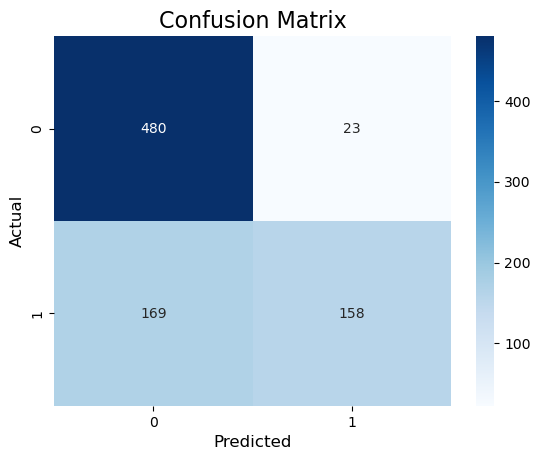

In [172]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)  
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

Anche in questo caso le performance ottenute dal modello possono essere rappresentate graficamente dalla Confusion Matrix. Assumendo che la classe con etichetta 0 sia la classe "positiva" e la classe con etichetta 1 sia la classe "negativa", i dati sono stati classificati come:

* 480 true positives: dati appartenenti alla classe 0 e classificati come 0
* 169 false positives: dati appartenenti alla classe 1 ma classificati come 0
* 23 false negatives: dati appartenenti alla classe 0 ma classificati come 1
* 158 true negatives: dati appartenenti alla classe 1 e classificati come 1
Quindi, il modello classificata erroneamente un totale di 192 esempi -> **ERROR RATE = 23,14%** (Maggiore solo di SVM)

Plottiamo il grafico rappresentativo delle regioni decisionali per completare il processo di Data Visualization, attraverso la PCA:

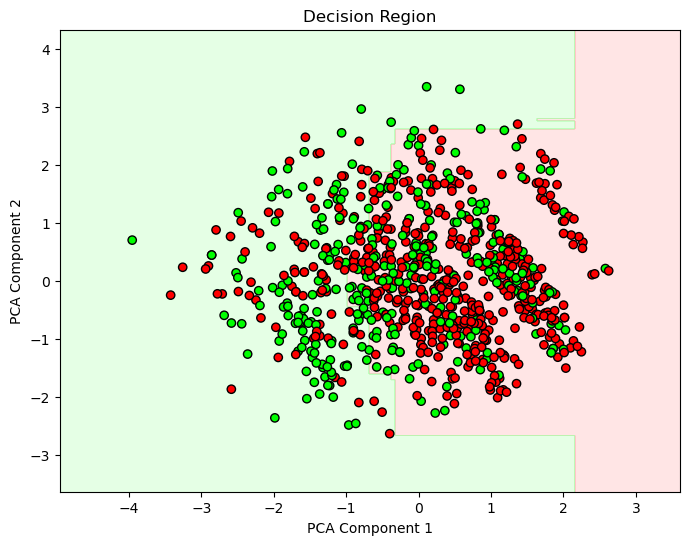

In [174]:
ada_pca=AdaBoostClassifier(n_estimators=100, random_state=42, learning_rate=0.1)
ada_pca.fit(x_train_pca, y_train)
plot_decision_regions(x_test_pca, y_test.values, ada_pca, 'Decision Region')

La vasta area verde sulla sinistra include numerosi punti rossi, confermando visivamente che il modello AdaBoost ha difficoltà a classificare correttamente molti campioni della classe 1 (generando falsi negativi), come già rilevato dall'analisi della matrice di confusione. Analogamente, ci sono punti verdi nell'area rosa, ma sembrano meno numerosi rispetto ai punti rossi nell'area verde, in linea con i risultati della matrice di confusione che mostravano meno falsi positivi rispetto ai falsi negativi.

# FASE 3: VALUTAZIONE DEI MODELLI: Evaluation Model and Model Selection

Il processo di valutazione dei modelli di apprendimento consiste nell'applicazione di una serie di tecniche atte a quantificare la qualità e la bontà del modello attraverso il calcolo di alcune metriche di performance. Durante l'implementazione dei modelli al dataset (Regressione Logistica con PFE, SVM con Kernel, Albero Decisionale e AdaBoost) è stata prodotta in output una matrice con delle metriche di valutazione che hanno mostrato un buon adattamento di questi ultimi al dataset. 

Abbiamo provveduto ad effettuare, attraverso il metodo della K-Fold Cross Validation e della Grid Search, una ricerca dei migliori iperparametri dei vari modelli che ne massimizzino le performance.
Successivamente, abbiamo rappresentato graficamente le curve di validazione che mostrano l'andamento delle performance al variare dei parametri per ogni modello ed infine la PRECISION-RECALL CURVE: sull'asse delle x troviamo la Recall, mentre sulla y la Precision; ogni punto della curva rappresenta un diverso valore di soglia di classificazione. Più la curva si trova in alto a destra e migliore è il classificatore. In particolare, abbiamo rappresentato la P-R curve per la classe 1, ovvero la minoritaria e quella più trascurata dagli algoritmi nella fase di predizione: è la classe con recall più bassa. Dato che:
* la classe 1 rappresenta i dipendenti che decidono di lasciare l'azienda;
* l'obiettivo del progetto è quello di riuscire a prevedere questa classe per poter evitare grandi perdite alle aziende e garantire l'ottimizzazione delle risorse umane;
* il bilanciamento del dataset mantiene il divario tra la classe 0 e la classe 1 in termini di predizioni corrette effettuata,

abbiamo deciso di basare la decisione sul miglior classificatore anche in termini di quello che riesce ad avere delle performance migliori sulla classe 1.

## 1. Regressione Logistica con Polynomial Feature Mapping

Consideriamo gli iperametri che caratterizzano il modello in questione: grado polinomiale della Polynomial Feature Mapping ('degree_values') e iperparamentro regolatore C ('C_values').

L'obiettivo è quello di trovare la combinazione ottima dei valori di questi due iperparametri, in modo da garantire le migliori performance per il modello. A tal fine, si utilizzano le tecniche della Grid Search e K-Fold Cross Validation, che esplorano in maniera esaustiva tutte le possibili combinazioni all’interno di un insieme predefinito di valori:

* C = [0.01, 0.1, 1.0, 10., 100.]

* degree = range(1,5)

In ultima istanza, vengono scelti e stampati come output i valori degli iperparametri che garantiscono una maggior accuracy.

In [179]:
pipe_lr.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'polynomialfeatures', 'standardscaler', 'logisticregression', 'polynomialfeatures__degree', 'polynomialfeatures__include_bias', 'polynomialfeatures__interaction_only', 'polynomialfeatures__order', 'standardscaler__copy', 'standardscaler__with_mean', 'standardscaler__with_std', 'logisticregression__C', 'logisticregression__class_weight', 'logisticregression__dual', 'logisticregression__fit_intercept', 'logisticregression__intercept_scaling', 'logisticregression__l1_ratio', 'logisticregression__max_iter', 'logisticregression__multi_class', 'logisticregression__n_jobs', 'logisticregression__penalty', 'logisticregression__random_state', 'logisticregression__solver', 'logisticregression__tol', 'logisticregression__verbose', 'logisticregression__warm_start'])

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import GridSearchCV

#La pipeline mi serve per includere nel modello di Regressione Logistica anche la trasformazione polinomiale
pipe_lr.fit(x_train, y_train)
C_values = [0.01, 0.1, 1.0, 10., 100.]
degree_values = [d for d in range(1,5)]

param_grid =[{'logisticregression__C':C_values,
              'polynomialfeatures__degree':degree_values}]

grid_search = GridSearchCV(pipe_lr, param_grid, cv=10, scoring='accuracy')
grid_search.fit(x_train_scaled, y_train) 

# Valutazione del modello migliore
print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior punteggio (cross-validation): {round(grid_search.best_score_,2)}\n")

# Predizioni e valutazione sul test set
y_pred = grid_search.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

Migliori parametri: {'logisticregression__C': 1.0, 'polynomialfeatures__degree': 3}
Miglior punteggio (cross-validation): 0.78

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       503
           1       0.81      0.65      0.72       327

    accuracy                           0.80       830
   macro avg       0.80      0.78      0.78       830
weighted avg       0.80      0.80      0.80       830



* Accuracy: prima pari al 73% e dopo pari al 78%. In questo caso in cui è stato mantenuto il lieve sbilanciamento del dataset, l'Accuracy potrebbe non dare una adeguata misura dell'effettiva efficacia del modello;
* Precision: complessivamente migliorata per entrambe le classi, superando il valore dell'80%;
* Recall: Per una variazione minima della classe 0, si è ridotto molto il divario con la classe 1. 

Anche per l'F1-score il divario tra le due classi si è attenuato di molto.

Trovati gli iperparametri ottimi, verifichiamo l'andamento della training e validation accuracy al variare dei due iperparametri sensibili identificati, tramite le curve di validazione.

**ERRORE DI GENERALIZZAZIONE = 1 - 0.78 = 0.22**

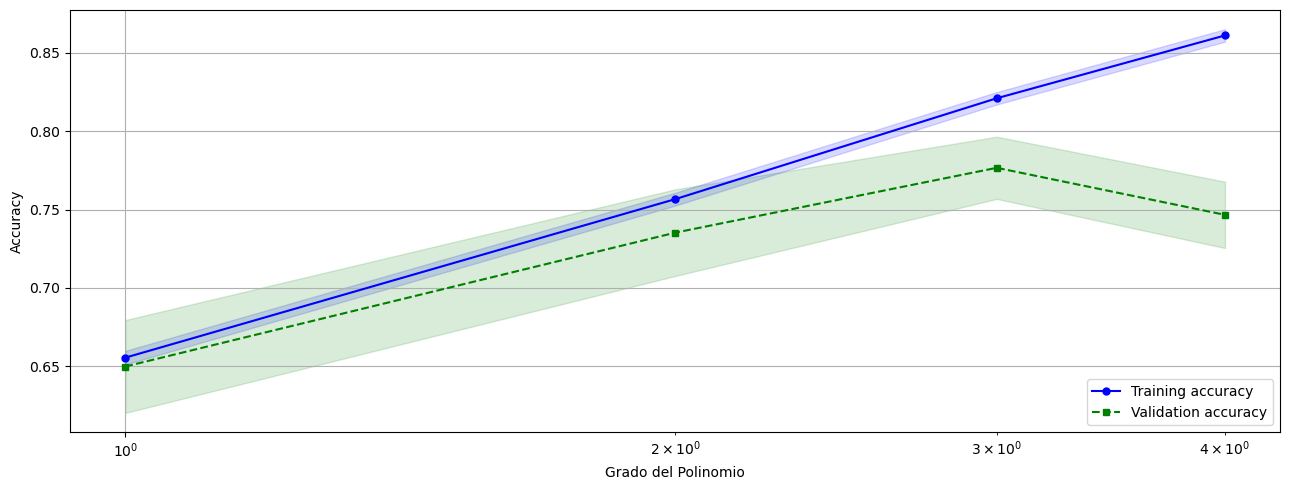

In [102]:
from sklearn.model_selection import validation_curve

# Validation curve per degree
train_scores, valid_scores= validation_curve(
    pipe_lr,
    X=x_train_scaled,
    y=y_train,
    param_name='polynomialfeatures__degree',
    param_range=degree_values,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(valid_scores, axis=1)
test_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(13,5))

plt.plot(degree_values, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(degree_values, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(degree_values, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(degree_values, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

Si osserva che la scelta del grado del polinomio utilizzato per l’espansione delle feature è cruciale per le prestazioni del modello: un grado troppo elevato tende a causare overfitting, invece un grado troppo basso garantisce similarità tra le curve ma a performance molto basse (underfitting). 

Nel caso specifico di un’espansione polinomiale di grado 4, si rileva una discrepanza di circa 0.1 punti tra l’accuracy sul training set e quella sul validation set, indicando un rischio di sovradattamento.

Attraverso l'utilizzo della Grid Search, è stato identificato come ottimale il valore degree = 3. A questo livello, le accuracy ottenute sui due set risultano le più elevate rispetto agli altri gradi testati, mantenendo al contempo una buona coerenza tra training e validation.

Sebbene anche in corrispondenza di questo valore si osservi una leggera divergenza tra le curve di accuratezza, la differenza è contenuta e giustificabile, indicando una buona capacità del modello di generalizzare senza incorrere in overfitting significativo.

Consideriamo ora l'andamento dell'iperparametro proprio della Regressione Logistica, ossia l'iperparametro regolatore C:

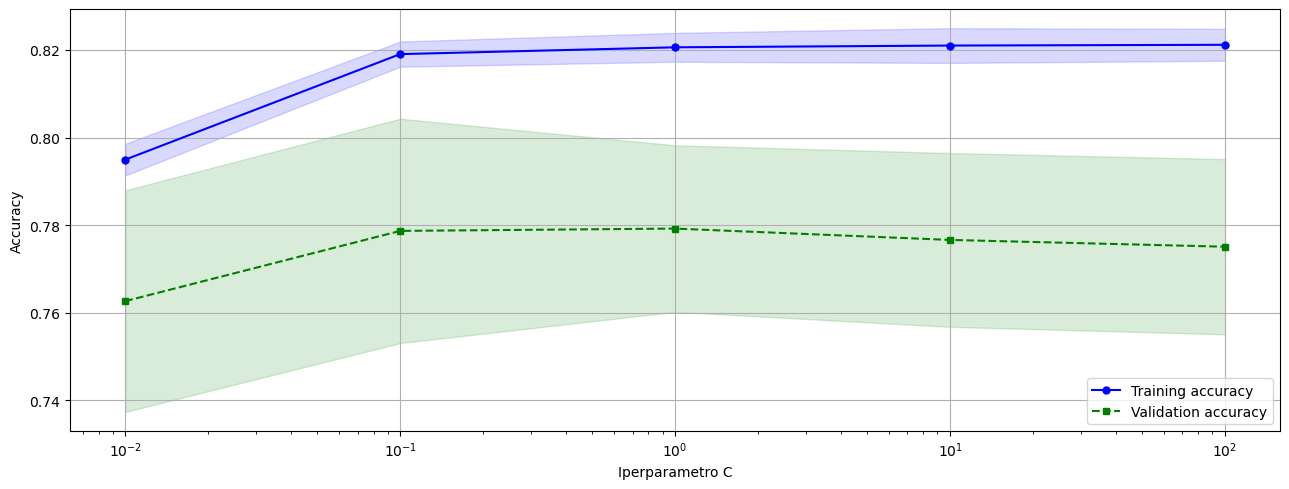

In [251]:
# Validation curve per C
train_scores, valid_scores = validation_curve(
    pipe_lr,
    X=x_train_scaled,
    y=y_train,
    param_name='logisticregression__C',
    param_range=C_values,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(valid_scores, axis=1)
test_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(13,5))

plt.plot(C_values, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(C_values, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(C_values, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(C_values, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Iperparametro C')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

Il grafico evidenzia una discrepanza tra le curve di accuratezza su training e validation set, seppur contenuta all'interno di un intervallo ristretto, compreso tra 0.3 e 0.4 punti, indicando una variazione relativamente bassa delle performance.

Il valore ottimale dell'iperparametro C, precedentemente individuato tramite grid search, è C = 1 (equivalente a 10^0). Questo valore rappresenta il miglior compromesso tra bias e varianza: garantisce infatti la massima accuratezza sul validation set e, allo stesso tempo, la minima discrepanza tra training e validation, segno di una buona generalizzazione.

Per valori di C più elevati, si osserva un miglioramento delle performance sul training set, ma senza alcun beneficio, o addirittura con un peggioramento, sul validation set (overfitting). Al contrario, valori di C inferiori al punto ottimale portano a una riduzione delle performance su entrambi i set.

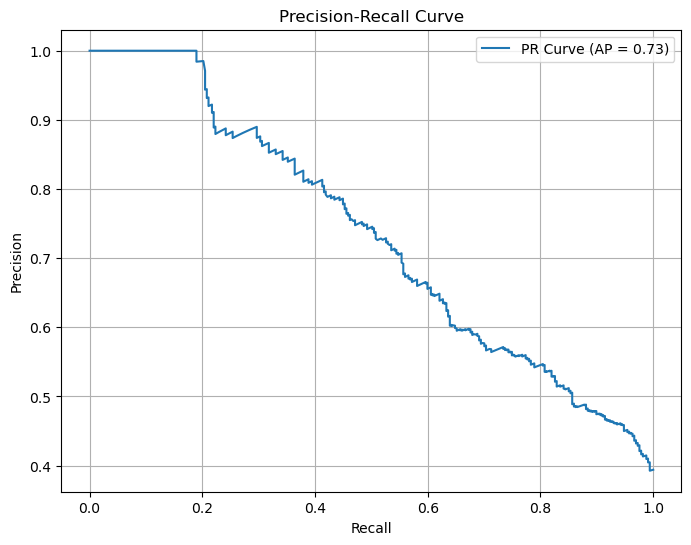

In [107]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = pipe_lr.predict_proba(x_test)[:, 1] #Classe 1 (dipendenti che lasciano)

# Calcolo precision, recall e soglie
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcolo dell'area sotto la curva (Average Precision)
ap_score = average_precision_score(y_test, y_scores)

# Plot della curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Average Precision pari al 73%: rappresenta l'area sotto la curva e indica la capacità del modello di mantenere le due misure di performance allo stesso livello. L'algoritmo riesce a mantenere bene una precision alta quando inizia a predire gli elementi della classe 1. 
In questo caso il modello, all'aumentare della Recall, riduce la precision: questo vuol dire che, una minore precision provoca un aumento dei falsi positivi. È la prova del fatto che all'aumentare delle predizioni corrette sulla classe 1, il modello inizia a predire sempre più falsi positivi ed in corrispondenza di una Recall pari a 1, la Precision scende al 40%.

## 2. SVM con Kernel

Nel caso di SVM con Kernel, consideriamo i seguenti due iperparametri:
* gamma = [0.01, 0.1, 1.0, 5, 10.]
* C = [0.01, 0.1, 1.0, 10., 100.]


In [109]:
from sklearn.svm import SVC

gamma_values = [0.01, 0.1, 1.0, 5, 10.]

param_grid = [{'C': C_values, 
               'gamma': gamma_values, 
               'kernel': ['rbf']},]

# Creazione e addestramento di GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=10, scoring='accuracy')
grid_search.fit(x_train_scaled, y_train)

# Valutazione del modello migliore
print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior punteggio (cross-validation): {round(grid_search.best_score_,2)}")

# Predizioni e valutazione sul test set
print("---------")
print("valutazione del modello su dataset di test\n")
y_pred = grid_search.predict(x_test_scaled)
print(classification_report(y_test, y_pred))

Migliori parametri: {'C': 10.0, 'gamma': 0.1, 'kernel': 'rbf'}
Miglior punteggio (cross-validation): 0.8
---------
valutazione del modello su dataset di test

              precision    recall  f1-score   support

           0       0.79      0.94      0.86       503
           1       0.87      0.61      0.71       327

    accuracy                           0.81       830
   macro avg       0.83      0.77      0.78       830
weighted avg       0.82      0.81      0.80       830



Utilizzando la Grid Search e la Cross-Validation (con cv=10) troviamo la combinazione migliore dei parametri C (10.0) e gamma (0.1) che hanno portato al miglior punteggio medio di accuratezza durante la cross-validation sul training set. 

Miglior punteggio (cross-validation): 0.8, rappresenta l'accuratezza media ottenuta sul training set attraverso la cross-validation a 10 fold, utilizzando i migliori iperparametri trovati. Indica una buona capacità predittiva del modello sui dati di training, stimando la sua performance su dati non visti all'interno del training process. 

Per la classe 0, il modello ha un recall molto alto (0.94), identificando correttamente la quasi totalità dei campioni di questa classe. La precision (0.79), pur implicando che circa il 21% delle predizioni come classe 0 sono errate, è sicuramente migliore della precision ottenuta precedentemente (72%). L'F1-score (0.86) riflette un'ottima performance complessiva sulla classe 0.

Per la classe 1, il modello ha una precisione più alta (0.87) rispetto alla classe 0, significando che quando predice la classe 1 è molto probabile che sia corretto. Tuttavia, il recall è significativamente più basso (0.61), indicando che il modello non riesce a identificare correttamente il 39% dei campioni della classe 1 (falsi negativi), ma anche in questo caso è migliorato rispetto alla recall iniziale (47%).  L'F1-score (0.71) è discreto. 

L'applicazione della Grid Search e Cross-Validation ha permesso di trovare una buona combinazione di iperparametri per il modello SVM con kernel, portando a un'accuratezza dell'80% sul test set, maggiore dell’accuratezza precedentemente ottenuta pari al 79%. 

**ERRORE DI GENERALIZZAZIONE = 1 - 0.8 = 0.2**

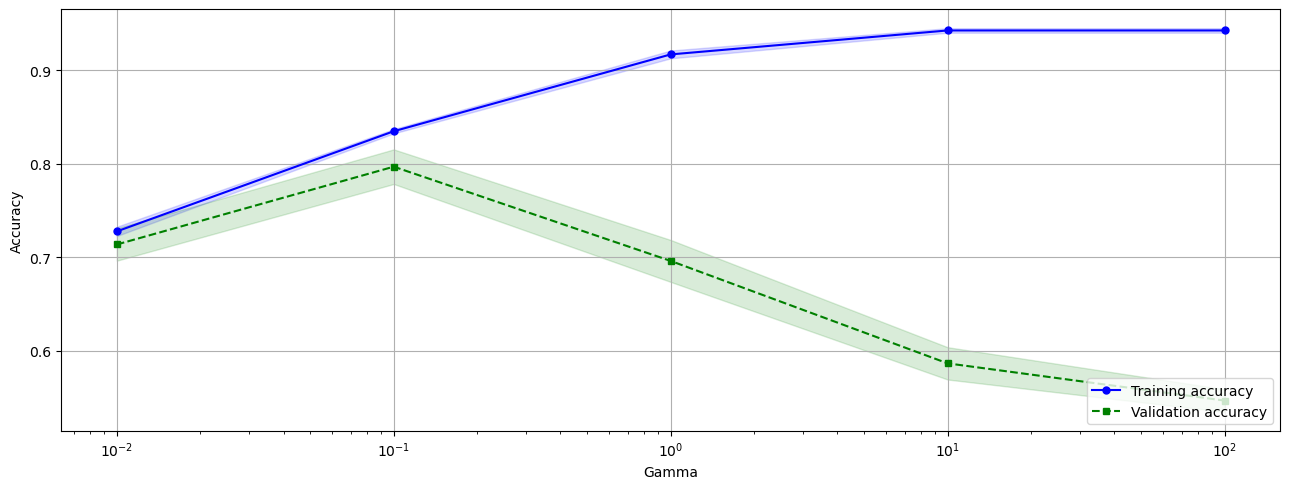

In [188]:
from sklearn.model_selection import validation_curve

# Validation curve per gamma
gamma=[0.01, 0.1, 1.0, 10., 100.]
train_scores, valid_scores = validation_curve(
    svm,
    X=x_train_scaled,
    y=y_train,
    param_name='gamma',
    param_range=gamma,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(valid_scores, axis=1)
test_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(13,5))

plt.plot(gamma, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(gamma, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(gamma, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(gamma, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Gamma')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

 Il grafico della Validation Curve conferma perché la Grid Search ha selezionato gamma = 0.1 come miglior parametro. Questo valore corrisponde al picco della curva di Validation accuracy, indicando che è il valore che ha mostrato la migliore capacità di generalizzazione (stimata tramite cross-validation) tra quelli testati. I valori di gamma più bassi portavano a underfitting (in questa regione del grafico entrambe le linee mostrano valori bassi o moderati di accuratezza) mentre i valori più alti a overfitting (in questa regione del grafico la linea blu raggiunge valori molto alti, mentre la linea verde tratteggiata diminuisce drasticamente, si osserva un ampio divario crescente tra le due curve).


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


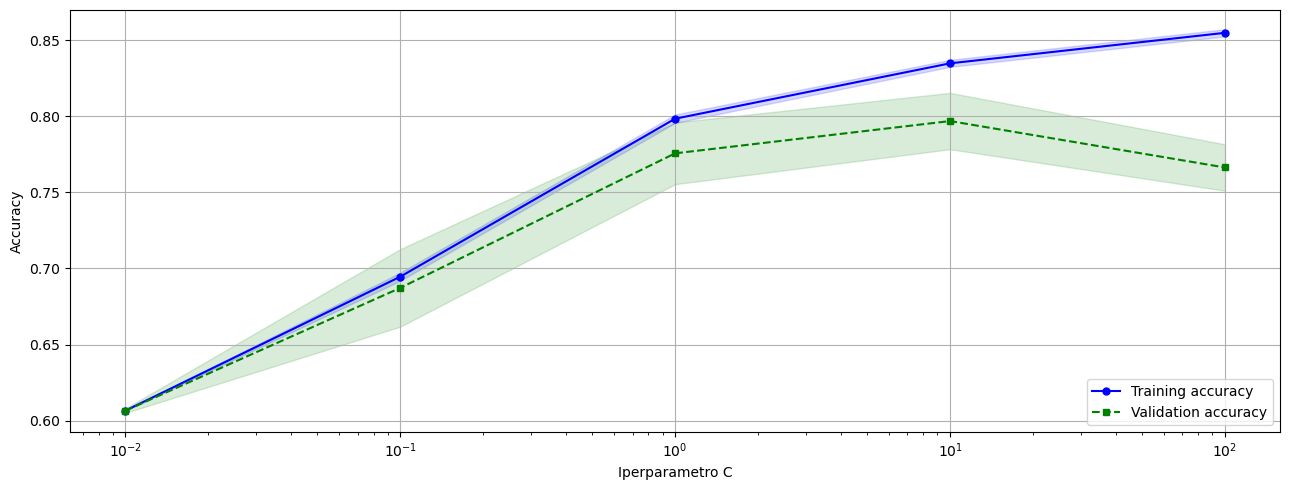

In [229]:
# Validation curve per C
train_scores_deg, valid_scores_deg = validation_curve(
    svm,
    X=x_train_scaled,
    y=y_train,
    param_name='C',
    param_range=C_values,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores_deg, axis=1)
train_std = np.std(train_scores_deg, axis=1)
test_mean = np.mean(valid_scores_deg, axis=1)
test_std = np.std(valid_scores_deg, axis=1)

plt.figure(figsize=(13,5))

plt.plot(C_values, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(C_values, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(C_values, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(C_values, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Iperparametro C')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

Il grafico della Validation Curve conferma visivamente il risultato della Grid Search che ha identificato C=10.0 come il miglior iperparametro per C (tenendo fisso gamma=0.1 come precedentemente discusso o come valore per questa specifica curva). Il picco della Validation accuracy nel grafico corrisponde esattamente a C=10.0. All’aumentare di C si sposta il modello da una condizione di underfitting (troppo semplice) verso un buon compromesso e infine verso l'overfitting per entrambe le curve.

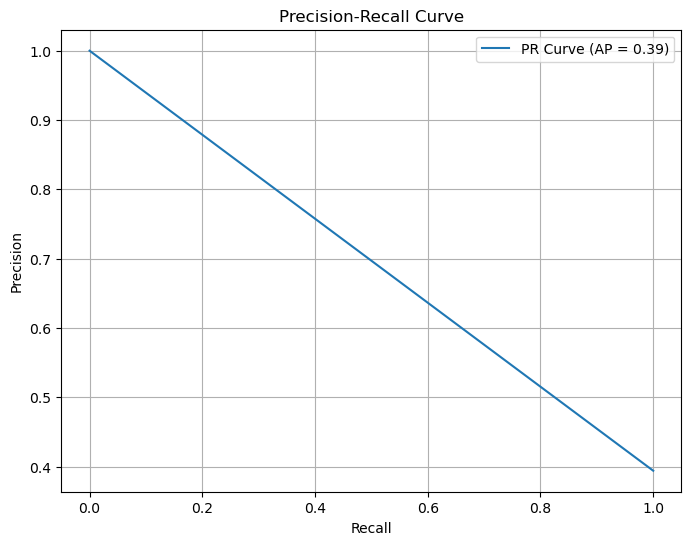

In [111]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = svm.predict_proba(x_test)[:, 1]

# Calcolo precision, recall e soglie
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcolo dell'area sotto la curva (Average Precision)
ap_score = average_precision_score(y_test, y_scores)

# Plot della curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Average Precision pari al 39%: questo vuol dire che ogni volta che l'algoritmo predice correttamente un elemento della classe positiva, i falsi positivi aumentano e la precision si riduce bruscamente. Il modello non riesce a classificare bene le due classi. 

## 3. Albero Decisionale

Nel caso dell'Albero Decisionale, consideriamo il seguente iperparametro:

depth = range(2,8)

In [191]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [193]:
tree.get_params().keys()

dict_keys(['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state', 'splitter'])

In [113]:
depth = [d for d in range(2,8)]

param_grid = [{'max_depth': depth}]

# Creazione e addestramento di GridSearchCV
grid_search = GridSearchCV(tree, param_grid, cv=10, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Valutazione del modello migliore
print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior punteggio (cross-validation): {round(grid_search.best_score_,2)}")

# Predizioni e valutazione sul test set
print("---------")
print("valutazione del modello su dataset di test\n")
y_pred = grid_search.predict(x_test)
print(classification_report(y_test, y_pred))

Migliori parametri: {'max_depth': 7}
Miglior punteggio (cross-validation): 0.8
---------
valutazione del modello su dataset di test

              precision    recall  f1-score   support

           0       0.78      0.94      0.85       503
           1       0.86      0.59      0.70       327

    accuracy                           0.80       830
   macro avg       0.82      0.77      0.78       830
weighted avg       0.81      0.80      0.79       830



Dopo aver individuato l'iperparametro da ottimizzare in modo tale da poter ottenere le performance migliori in assoluto, per una profondità pari a 7, rispetto alla depth pari a 3 utilizzata in fase di training, la K-Fold Cross Validation e la Greed Search portano ad ottenere metriche di efficacia del modello leggermente maggiori:

1. Accuracy: prima pari al 74,22% e dopo pari all'80%. In questo caso in cui è stato mantenuto il lieve sbilanciamento del dataset, l'Accuracy potrebbe non dare una adeguata misura dell'effettiva efficacia del modello;
2. Precision: migliore in entrambi i casi;
3. Recall: è lievemente migliorata nella classe 1 , riducendo anche in questo caso il divario con la classe 0.

4. Anche F1-score presenta una particolare differenza di punteggio tra le due classi ma, in seguito alla validation, il valore aumenta.

**ERRORE DI GENERALIZZAZIONE = 1 - 0.8= 0.2**

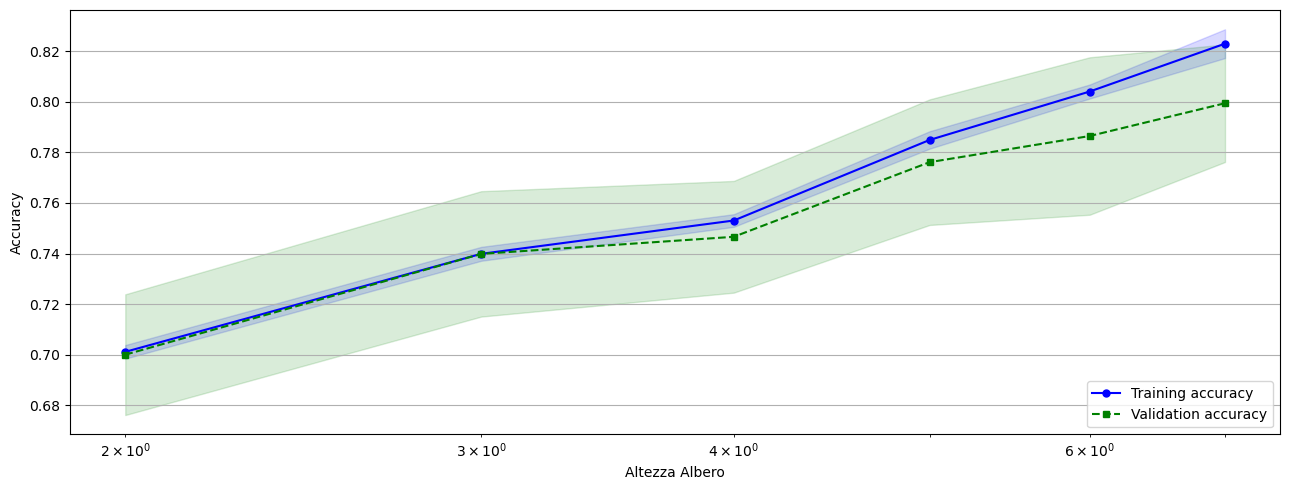

In [197]:
# Validation curve per depth
train_scores, valid_scores = validation_curve(
    tree,
    X=x_train,
    y=y_train,
    param_name='max_depth',
    param_range=depth,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(valid_scores, axis=1)
test_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(13,5))

plt.plot(depth, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(depth, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(depth, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(depth, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Altezza Albero')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

Dal grafico che mostra le curve di validazione in fase di training dell'algoritmo ed in fase di validazione degli iperparametri, è possibile osservare come in corrispondenza di una profondità pari a 7, decretata come migliore dall'analisi precedente, il modello presenta un lieve overfitting: in questo caso si potrebbe semplificare il modello scegliendo una profondità dell'albero pari a 6, riducendo l'onerosità computazionale e anche l'eccessivo adattamento ai dati del decision tree.

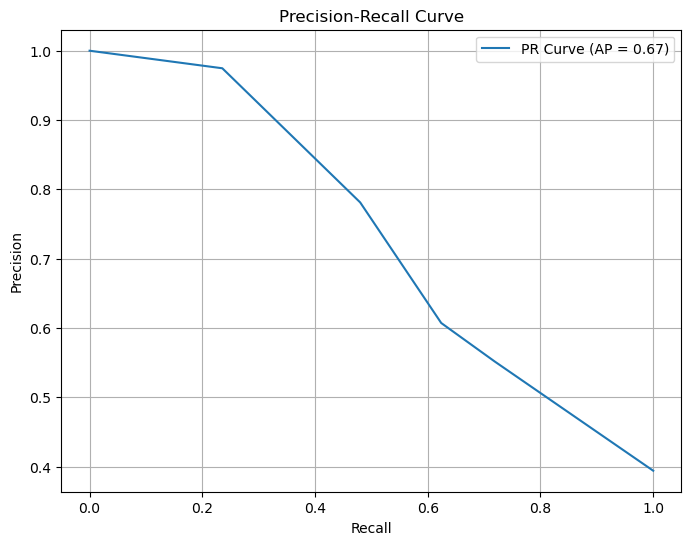

In [115]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = tree.predict_proba(x_test)[:, 1]

# Calcolo precision, recall e soglie
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcolo dell'area sotto la curva (Average Precision)
ap_score = average_precision_score(y_test, y_scores)

# Plot della curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

L'Average Precision al 67% e l'andamento della curva mostrano che, finchè la precision è intorno a 1, la recall è bassa, ma dal momento in cui il modello inizia a cercare elementi della classe 1, la precision si riduce bruscamente, a scapito di un aumento notevole dei falsi positivi. Il modello riesce nel complesso a bilanciare discretamente le due misure.

## 4. AdaBoost

Nel caso di AdaBoost, consideriamo i seguenti iperparametri:

* learning rate: [0.001, 0.01, 0.1, 0.5, 1]
* stimatori = [10, 50, 100, 200, 300, 500, 1000]

In [200]:
ada.get_params().keys()

dict_keys(['algorithm', 'estimator', 'learning_rate', 'n_estimators', 'random_state'])

In [129]:
learning_rate = [0.001, 0.01, 0.1, 0.5, 1]
n_estimators = [10, 50, 100, 200, 300, 500, 1000]
param_grid = [{'learning_rate': learning_rate, 'n_estimators':n_estimators}]

# Creazione e addestramento di GridSearchCV
grid_search = GridSearchCV(ada, param_grid, cv=10, scoring='accuracy')
grid_search.fit(x_train, y_train)

# Valutazione del modello migliore
print(f"Migliori parametri: {grid_search.best_params_}")
print(f"Miglior punteggio (cross-validation): {round(grid_search.best_score_,2)}")

# Predizioni e valutazione sul test set
print("---------")
print("valutazione del modello su dataset di test\n")
y_pred = grid_search.predict(x_test)
print(classification_report(y_test, y_pred))

Migliori parametri: {'learning_rate': 0.1, 'n_estimators': 500}
Miglior punteggio (cross-validation): 0.76
---------
valutazione del modello su dataset di test

              precision    recall  f1-score   support

           0       0.76      0.91      0.83       503
           1       0.80      0.55      0.65       327

    accuracy                           0.77       830
   macro avg       0.78      0.73      0.74       830
weighted avg       0.78      0.77      0.76       830



1. Accuracy: prima pari al 76,87% e dopo pari all'76%. In questo caso in cui è stato mantenuto il lieve sbilanciamento del dataset, l'Accuracy potrebbe non dare una adeguata misura dell'effettiva efficacia del modello; Essendo la Cross Validation un metodo che seleziona quegli ipermerametri che danno le performance mediamente più elevate, questo potrebbe portare ad una riduzione di alcune metriche in modo lieve.
2. Precision: aumenta per entrambe le classi;
3. Recall: aumenta per entrambe le classi riducendo il divario;
4. Anche F1-score presenta una particolare differenza di punteggio tra le due classi ma, in seguito alla validation, il valore aumenta.

**ERRORE DI GENERALIZZAZIONE = 1- 0.76 = 0.24**

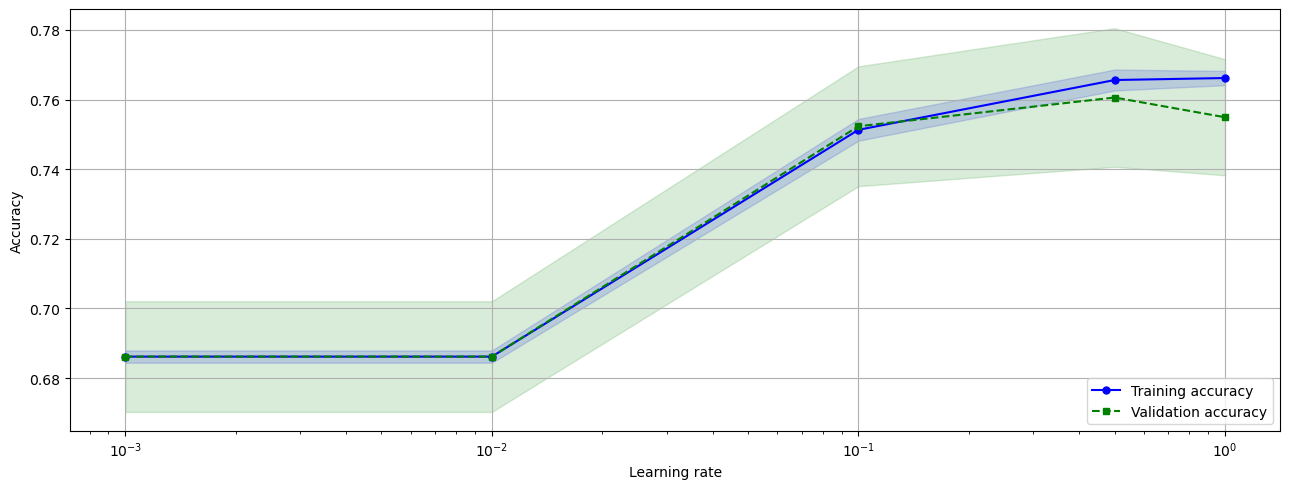

In [257]:
# Validation curve per learning rate
train_scores, valid_scores = validation_curve(
    ada,
    X=x_train,
    y=y_train,
    param_name='learning_rate',
    param_range=learning_rate,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(valid_scores, axis=1)
test_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(13,5))

plt.plot(learning_rate, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(learning_rate, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(learning_rate, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(learning_rate, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Learning rate')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

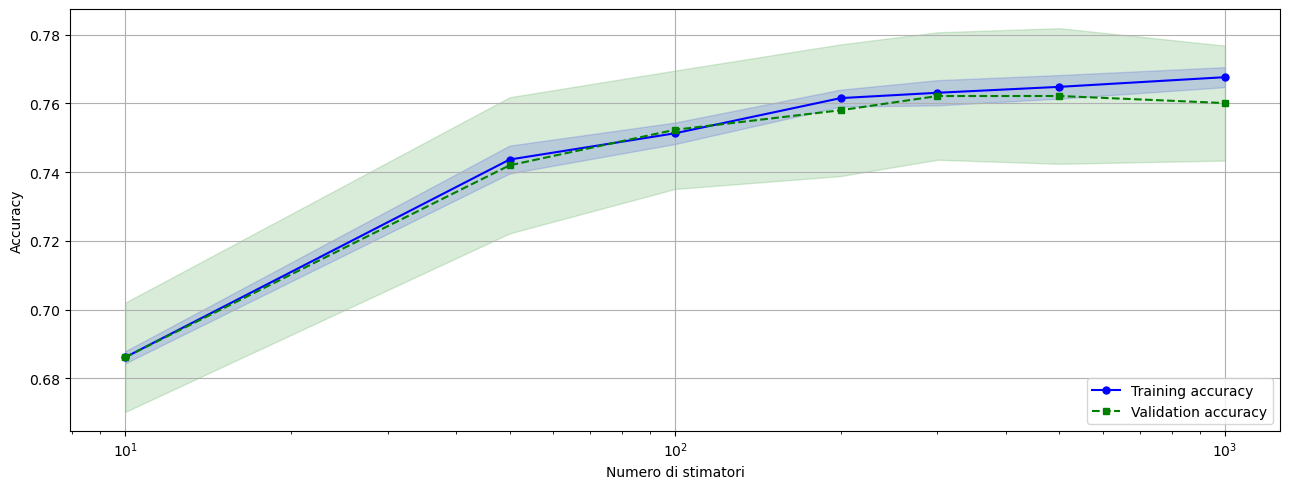

In [114]:
# Validation curve per numero stimatori
train_scores_deg, valid_scores_deg = validation_curve(
    ada,
    X=x_train,
    y=y_train,
    param_name='n_estimators',
    param_range=n_estimators,
    cv=10,
    scoring='accuracy'
)

train_mean = np.mean(train_scores_deg, axis=1)
train_std = np.std(train_scores_deg, axis=1)
test_mean = np.mean(valid_scores_deg, axis=1)
test_std = np.std(valid_scores_deg, axis=1)

plt.figure(figsize=(13,5))

plt.plot(n_estimators, train_mean, 
         color='blue', marker='o', 
         markersize=5, label='Training accuracy')

plt.fill_between(n_estimators, train_mean + train_std,
                 train_mean - train_std, alpha=0.15,
                 color='blue')

plt.plot(n_estimators, test_mean, 
         color='green', linestyle='--', 
         marker='s', markersize=5, 
         label='Validation accuracy')

plt.fill_between(n_estimators, 
                 test_mean + test_std,
                 test_mean - test_std, 
                 alpha=0.15, color='green')

plt.grid()
plt.xscale('log')
plt.legend(loc='lower right')
plt.xlabel('Numero di stimatori')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

Dal grafico, che mostra le curve di validazione in fase di training dell'algoritmo ed in fase di validazione degli iperparametri, è possibile osservare come per valori degli iperparametri superiori a quelli ottimali (learning rate pari a 0.1 e 500 stimatori) il modello presenta un lieve overfitting. La k-Fold Cross Validation e la Greed Search hanno individuato quei valori in corrispondenza dei quali le curve di training e validation raggiungono i loro punti più alti.
Per valori del learning rate pari a 0.001 e un numero di stimatori pari a 10, il modello è in underfitting: ottiene basse performance sia in fase di training che in fase di test.


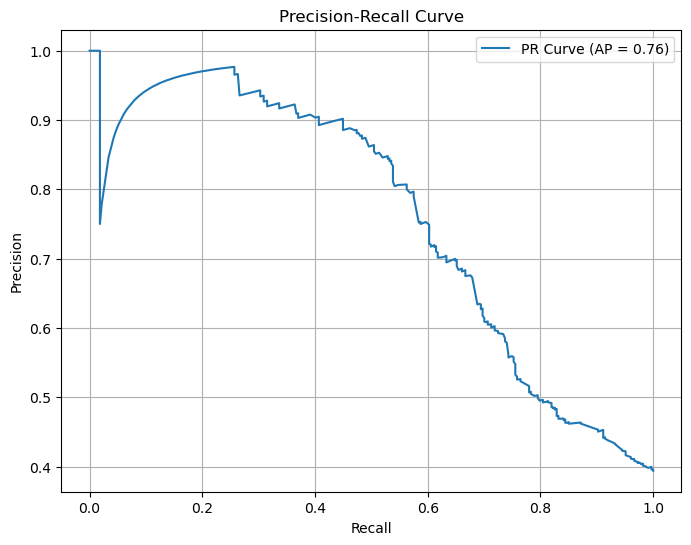

In [131]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

y_scores = ada.predict_proba(x_test)[:, 1]

# Calcolo precision, recall e soglie
precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

# Calcolo dell'area sotto la curva (Average Precision)
ap_score = average_precision_score(y_test, y_scores)

# Plot della curva Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()

Average Precision pari al 76% presuppone un ottima performance e combinazione di Recall e Precision da parte dell'algoritmo nella classe 1. Ha un andamento particolare: quando la recall aumenta leggermente, la precision crolla per un brusco aumento dei falsi positivi, ma prosegue in aumento fino ad una Recall pari al 25% circa. Con un aumento dei Falsi Positivi, la curva decresce all'aumentare della Recall. 

## Confronto tra modelli:
Per giungere ad una conclusione e poter scegliere il miglior modello per la predizione dei dipendenti che lasciano il lavoro o meno, coerentemente con il ragionamento portato avanti fino ad ora, abbiamo deciso di utilizzare 3 metriche decisionali: 

1. **Delta delle Recall tra classe 0 e classe 1**: la Recall, in quanto fornisce una misura di accuratezza migliore sulla predizione delle classi su un dataset sbilanciato. I modelli che hanno mostrato variazioni inferiori sono:
   * Regressione Logistica: presenta un delta pari al 25%
   * SVM con Kernel: presenta un delta tra le due classi par a 33%.

Dai grafici che mostrano la Precision-Recall Curve di tutti e 4 i modelli (una curva che indica l'equilibrio tra la Precision e la Recall quando il classificatore effettua le predizioni sulla variabile target), è evidente come entrambi riescano a mantenere un buon livello di Average Precision sulla classe minoritaria (classe 1) rispettivamente pari al 73% (RL) e al 76% (SVM).

2.  **Accuracy**: in termini di accuratezza del modello, considerando gli iperparametri ottimi individuati nella fase precedente i livelli ottenuti sono:
   * Regressione Logistica con Polynomial Feature Mapping: 78%
   * SVM con Kernel: 80%

Quelli che riescono ad ottenere un maggior valore sono SVM con Kernel e Regressione Logistica Polinomiale. Tenendo conto del fatto che l'applicazione dei modelli è avvenuta su un dataset lievemente sbilanciato, è necessario approfondire l'analisi anche sulla base di altre metriche. Il contesto del dataset (nel nostro caso aziendale) può prevedere, diversamente da altri contesti (ad esempio quello medico), la scelta di un algoritmo con meno punti percentuali in termini di Accuracy ma con un grado di complessità e onerosità di calcolo inferiori.

3. **Complessità dei modelli**: analizziamo la complessità dei due modelli con migliore Accuracy sulla base degli iperparametri ottimi.
   * SVM con Kernel: presenta un valore di gamma relativamente basso all'interno dell'intervallo considerato, pari a 0.1 e C=10; 
   * Regressione Logistica con Feature Mapping: presenta un valore del degree pari a 3.

Il feature mapping (ad esempio di grado 3) aggiunge nuove colonne al dataset combinando le variabili tra loro in modo da permettere alla regressione logistica di trovare confini curvi, non solo lineari. Questo rende il modello più potente, ma rimane semplice nel modo in cui viene allenato: non serve confrontare ogni punto con tutti gli altri, come fa la SVM. La regressione, quindi, lavora su un dataset più grande (con più colonne), ma lo fa in modo diretto e lineare, non costruendo una matrice di confronti tra tutti i punti. Invece, il prodotto interno tra vettori a dimensionalità alta, rende il kernel computazionalmente oneroso.

In conclusione, secondo i criteri scelti, possiamo affermare che il miglior modello di Classificazione Binaria sul dataset prescelto è la **Regressione Logistica con Polynomial Feature Mapping**: poiché l’applicazione è in ambito economico e non comporta rischi critici, abbiamo accettato un compromesso tra accuratezza e semplicità, privilegiando un modello interpretabile a fronte di una leggera perdita di performance.